<a href="https://colab.research.google.com/github/jarzolads/ML-BUAP-IBERO/blob/main/03_clasificacion_calidad_agua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

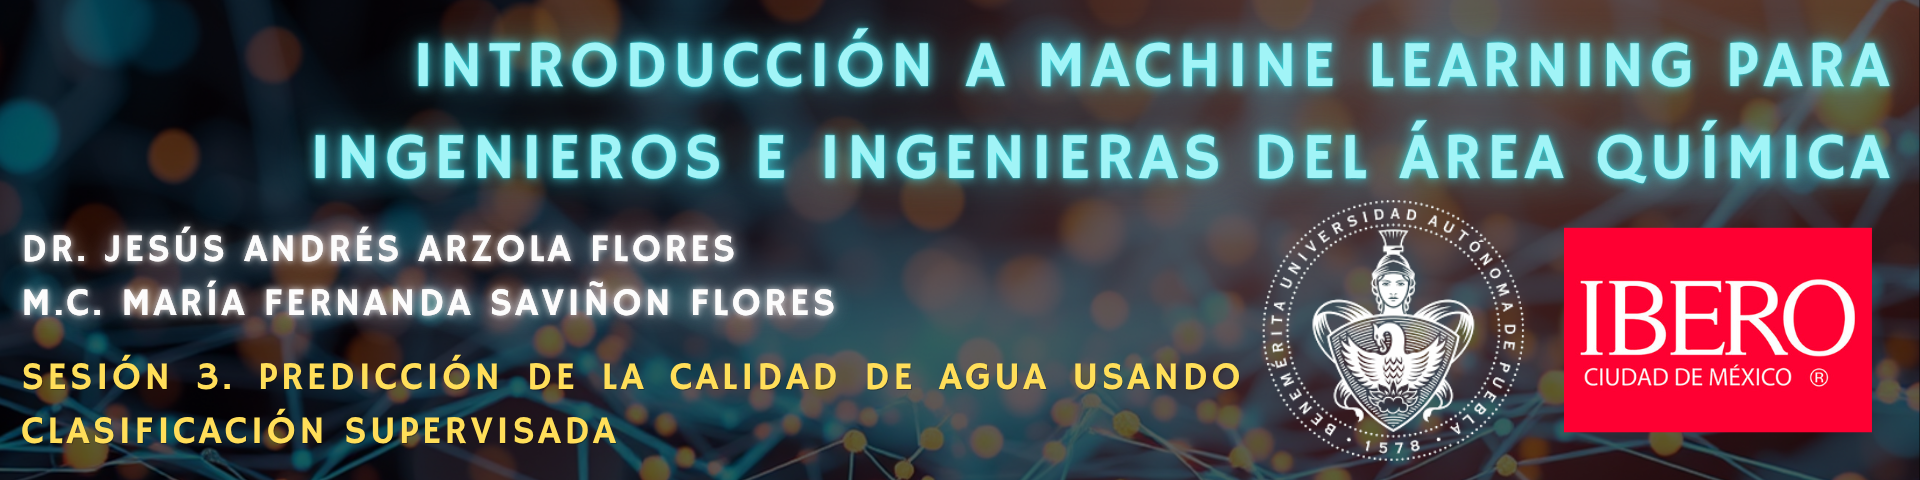

# Sesión 3. Clasificación de calidad de agua: Machine Learning para apoyar decisiones ambientales

**Curso:** Machine Learning introductorio para estudiantes de licenciatura del área química  
**Metodología:** Aprendizaje Basado en Casos  
**Duración:** 2 horas  
**Entorno:** Google Colab  

---

## Instrucción inicial

Antes de comenzar, guarda una copia de este notebook en tu Google Drive:

**Archivo → Guardar una copia en Drive**

Trabajarás sobre tu propia copia del archivo.


## 1. Contexto del caso

El acceso a agua de calidad adecuada es un tema crítico para la salud pública, la ingeniería ambiental, la operación de plantas de tratamiento, la gestión de recursos hídricos y la toma de decisiones en comunidades, industrias y laboratorios. La calidad del agua no depende de una sola variable, sino de la combinación de múltiples parámetros fisicoquímicos, como pH, turbidez, sólidos disueltos, conductividad, dureza, cloraminas, sulfatos, carbono orgánico y trihalometanos.

En un escenario real, una institución ambiental, una planta de tratamiento de aguas, un laboratorio de control de calidad o un organismo operador podría recibir numerosas muestras de agua y requerir una primera evaluación rápida sobre su posible condición: **potable** o **no potable**. Esta evaluación preliminar podría ayudar a priorizar muestras, identificar condiciones de riesgo, decidir si se requieren análisis adicionales o apoyar la toma de decisiones operativas.

Sin embargo, es importante aclarar que un modelo de Machine Learning **no sustituye** una evaluación normativa, sanitaria o experimental realizada mediante métodos oficiales. La clasificación generada por un modelo debe entenderse como una herramienta de apoyo, no como una certificación de potabilidad.

En este caso, se utilizará un conjunto de datos de calidad de agua que contiene mediciones fisicoquímicas y una variable de salida llamada `Potability`, donde:

| Valor | Interpretación |
|---|---|
| 0 | Agua no potable |
| 1 | Agua potable |

El objetivo será construir modelos de clasificación que aprendan patrones a partir de los datos disponibles y puedan clasificar nuevas muestras como potables o no potables.

Desde la perspectiva de ingeniería, este caso permite discutir varios aspectos importantes:

- la importancia de los datos de calidad;
- el tratamiento de valores faltantes;
- la presencia de clases desbalanceadas;
- la partición de datos en entrenamiento y prueba;
- la estratificación;
- la comparación de modelos;
- la interpretación de métricas;
- los riesgos de falsos positivos y falsos negativos;
- el uso responsable de modelos predictivos en problemas ambientales.

La pregunta no es solamente si el modelo puede clasificar, sino si sus resultados son suficientemente confiables e interpretables para apoyar una decisión ambiental.


## 2. Pregunta detonadora

**¿Puede un modelo de clasificación apoyar la toma de decisiones preliminares sobre calidad de agua a partir de variables fisicoquímicas?**

Esta pregunta permitirá analizar la diferencia entre construir un modelo con buen desempeño numérico y construir una herramienta útil, interpretable y responsable para un problema ambiental.


## 3. Objetivo de aprendizaje

Al finalizar esta sesión, el participante será capaz de:

- Reconocer un problema de clasificación supervisada.
- Identificar variables predictoras y variable objetivo.
- Comprender la importancia de revisar la distribución de clases.
- Explicar qué son las clases desbalanceadas y cómo pueden afectar un modelo.
- Comprender la importancia de la estratificación al dividir datos.
- Explicar qué son los datos faltantes y cómo se pueden imputar.
- Entrenar modelos de clasificación usando regresión logística y K vecinos cercanos.
- Evaluar modelos mediante matriz de confusión, accuracy, precision, recall, F1-score y curva ROC.
- Interpretar errores de clasificación en un contexto ambiental.
- Reflexionar sobre el uso responsable de Machine Learning en problemas de calidad de agua.


## 4. Conceptos básicos

### 4.1 ¿Qué es clasificación supervisada?

La **clasificación supervisada** se utiliza cuando se desea asignar una observación a una categoría conocida. Para entrenar el modelo se necesita un conjunto de datos donde cada muestra tenga:

- variables predictoras o características, por ejemplo pH, turbidez, conductividad;
- una etiqueta o clase conocida, por ejemplo potable o no potable.

En este caso:

$$X
\rightarrow y
$$

donde:

- $X$ representa las variables predictoras;
- $y$ representa la clase o etiqueta.

Para este problema:

$$X = [pH,\ turbidez,\ conductividad,\ sólidos,\ldots]
$$

$$y = 	Potability$$

La salida no es un valor continuo, sino una categoría:


$$y \in \{0,1\}$$

---

### 4.2 Clasificación binaria

Este caso corresponde a una **clasificación binaria**, porque solo existen dos clases:

| Clase | Significado |
|---|---|
| 0 | No potable |
| 1 | Potable |

En problemas ambientales, la clasificación binaria puede utilizarse para preguntas como:

- ¿El agua es potable o no potable?
- ¿Una muestra cumple o no cumple una especificación?
- ¿Una condición de operación es segura o insegura?
- ¿Un sensor está funcionando correctamente o presenta falla?

---

### 4.3 Precaución importante

Aunque el modelo clasifique una muestra como potable, eso no significa que el agua pueda consumirse sin verificación. La potabilidad depende de criterios normativos, microbiológicos, químicos y sanitarios más amplios. Por ello, el resultado del modelo debe entenderse como una **clasificación preliminar**.


## 5. Variables del conjunto de datos

El conjunto de datos contiene variables fisicoquímicas comunes en análisis de calidad de agua.

| Variable | Descripción general |
|---|---|
| `ph` | Medida de acidez o alcalinidad del agua. |
| `Hardness` | Dureza del agua, relacionada con sales de calcio y magnesio. |
| `Solids` | Sólidos disueltos totales. |
| `Chloramines` | Concentración de cloraminas usadas en desinfección. |
| `Sulfate` | Concentración de sulfatos. |
| `Conductivity` | Conductividad eléctrica del agua. |
| `Organic_carbon` | Carbono orgánico presente en el agua. |
| `Trihalomethanes` | Subproductos de desinfección. |
| `Turbidity` | Turbidez o dispersión de luz por partículas suspendidas. |
| `Potability` | Variable objetivo: 0 = no potable, 1 = potable. |

La variable objetivo será:

$$y = 	Potability$$

Las demás variables serán utilizadas como variables predictoras:

$$X = [ph, Hardness, Solids, Chloramines, Sulfate, Conductivity, Organic\_carbon, Trihalomethanes, Turbidity]$$


## 6. Referencias del caso y uso del conjunto de datos

Este notebook utiliza el conjunto de datos conocido como **Water Potability**, disponible en Kaggle y replicado en repositorios públicos para facilitar su uso educativo.

El conjunto de datos se utiliza aquí con fines didácticos para introducir clasificación supervisada. No debe utilizarse como referencia normativa o sanitaria.

### Referencias sugeridas

- Patel, H., Prajapati, N., y Shah, M. (2022). A machine learning-based water potability prediction model by using synthetic minority oversampling technique and explainable AI. *Computational Intelligence and Neuroscience*, 2022, 9283293. https://doi.org/10.1155/2022/9283293
- World Health Organization. (2022). *Guidelines for drinking-water quality: Fourth edition incorporating the first and second addenda*. World Health Organization.
- Chawla, N. V., Bowyer, K. W., Hall, L. O., y Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, 16, 321–357. https://doi.org/10.1613/jair.953
- He, H., y Garcia, E. A. (2009). Learning from imbalanced data. *IEEE Transactions on Knowledge and Data Engineering*, 21(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239
- Little, R. J. A., y Rubin, D. B. (2019). *Statistical analysis with missing data* (3.ª ed.). Wiley.
- Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters*, 27(8), 861–874. https://doi.org/10.1016/j.patrec.2005.10.010


## 7. Carga de librerías

Usaremos `pandas`, `numpy`, `matplotlib` y varios módulos de `scikit-learn`.

También se utilizarán `Pipeline` y herramientas de preprocesamiento para evitar fuga de información entre entrenamiento y prueba.


**Código 7. Cargar librerías.** Copia, revisa y ejecuta la siguiente celda de código:

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
```

In [24]:
#Escribe el código aquí

## 8. Carga del conjunto de datos

Primero intentaremos cargar el archivo desde un repositorio público en GitHub.

Si por alguna razón el enlace no funciona, puedes descargar manualmente el archivo `water_potability.csv` y cargarlo en Colab.


**Código 8. Cargar el conjunto de datos.** Copia, revisa y ejecuta la siguiente celda de código:

```python
url = "https://raw.githubusercontent.com/abideen-olawuwo/water-potability/main/water_potability.csv"

df = pd.read_csv(url)

df.head()
```

In [25]:
#Escribe el código aquí

**Código 8A. Revisar tamaño del conjunto de datos.** Copia, revisa y ejecuta la siguiente celda de código:

```python
df.shape
```

In [26]:
#Escribe el código aquí

**Código 8B. Revisar columnas disponibles.** Copia, revisa y ejecuta la siguiente celda de código:

```python
df.columns
```

In [27]:
#Escribe el código aquí

## 9. Revisión inicial del conjunto de datos

Antes de construir cualquier modelo es necesario revisar la estructura de los datos.

En esta etapa se busca responder:

- ¿Cuántas muestras hay?
- ¿Cuántas variables hay?
- ¿Hay valores faltantes?
- ¿Qué tipo de variables tenemos?
- ¿Cuál es el rango de las variables?

Esta revisión es fundamental porque un modelo de Machine Learning no corrige automáticamente problemas de calidad en los datos.


**Código 9. Revisar información general.** Copia, revisa y ejecuta la siguiente celda de código:

```python
df.info()
```

In [28]:
#Escribe el código aquí

**Código 9A. Contar valores faltantes por variable.** Copia, revisa y ejecuta la siguiente celda de código:

```python
df.isnull().sum()
```

In [29]:
#Escribe el código aquí

**Código 9B. Obtener estadística descriptiva.** Copia, revisa y ejecuta la siguiente celda de código:

```python
df.describe().round(2)
```

In [30]:
#Escribe el código aquí

## 10. Distribución de clases y clases desbalanceadas

Antes de entrenar un modelo de clasificación debemos revisar cuántas muestras hay de cada clase.

En este caso, la variable objetivo es `Potability`:

| Clase | Significado |
|---|---|
| 0 | No potable |
| 1 | Potable |

Un problema tiene **clases desbalanceadas** cuando una clase aparece con mucha mayor frecuencia que otra.

Por ejemplo:

| Clase | Número de muestras |
|---|---:|
| No potable | 900 |
| Potable | 100 |

En ese caso, el modelo podría aprender a clasificar casi todo como “no potable” y aun así obtener un accuracy alto. Sin embargo, ese modelo sería poco útil, porque no estaría identificando adecuadamente la clase minoritaria.

---

### ¿Por qué es importante atender el desbalance de clases?

El desbalance puede afectar la evaluación y el entrenamiento porque:

- el modelo puede favorecer la clase mayoritaria;
- el accuracy puede dar una impresión engañosa;
- se pueden incrementar falsos negativos o falsos positivos;
- la clase minoritaria puede ser justamente la más importante para la decisión;
- en problemas ambientales o sanitarios, un error puede tener consecuencias relevantes.

Por ejemplo, si el modelo clasifica agua no potable como potable, se tendría un **falso positivo** peligroso desde el punto de vista de salud pública.

---

### Estrategias para manejar clases desbalanceadas

Existen varias estrategias. La elección depende del problema, del tamaño del conjunto de datos, de la importancia de cada clase y del tipo de modelo.

| Estrategia | Idea principal | ¿Cuándo es útil? | Ejemplo en Python |
|---|---|---|---|
| Revisar métricas adecuadas | No depender solo de accuracy; usar precision, recall, F1, ROC-AUC o PR-AUC. | Siempre que exista desbalance. | `classification_report()` |
| Estratificación | Mantener proporción de clases en entrenamiento y prueba. | Cuando se divide el conjunto de datos. | `train_test_split(..., stratify=y)` |
| `class_weight='balanced'` | Dar mayor peso a la clase minoritaria durante el entrenamiento. | Modelos que soportan pesos de clase, como regresión logística. | `LogisticRegression(class_weight='balanced')` |
| Submuestreo | Reducir muestras de la clase mayoritaria. | Cuando hay muchos datos y se quiere equilibrar clases. | `RandomUnderSampler` de `imblearn` |
| Sobremuestreo | Aumentar muestras de la clase minoritaria duplicando o generando ejemplos. | Cuando hay pocos datos de la clase minoritaria. | `RandomOverSampler` de `imblearn` |
| SMOTE | Crear muestras sintéticas de la clase minoritaria. | Cuando se quiere aumentar la clase minoritaria sin copiar exactamente las mismas muestras. | `SMOTE` de `imblearn` |
| Ajuste del umbral | Cambiar el umbral de decisión de 0.5. | Cuando importa más reducir falsos positivos o falsos negativos. | Usar `predict_proba()` |

---

### Ejemplo conceptual de ajuste del umbral

En clasificación binaria, muchos modelos calculan una probabilidad:

$$P(y=1|X)$$

Por defecto, se suele clasificar como clase 1 si:

$$P(y=1|X) \geq 0.5$$

Pero en problemas ambientales, el umbral puede modificarse. Por ejemplo, si queremos ser más estrictos al clasificar agua como potable, podríamos usar:

$$P(y=1|X) \geq 0.7$$

Esto significa que solo se clasificaría como potable cuando el modelo tenga mayor confianza.

---

### Referencias sugeridas

- He, H., y Garcia, E. A. (2009). Learning from imbalanced data. *IEEE Transactions on Knowledge and Data Engineering*, 21(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239
- Chawla, N. V., Bowyer, K. W., Hall, L. O., y Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, 16, 321–357. https://doi.org/10.1613/jair.953


**Código 10. Revisar distribución de clases.** Copia, revisa y ejecuta la siguiente celda de código:

```python
conteo_clases = df['Potability'].value_counts().sort_index()
porcentaje_clases = df['Potability'].value_counts(normalize=True).sort_index() * 100

tabla_clases = pd.DataFrame({
    'clase': ['No potable', 'Potable'],
    'conteo': conteo_clases.values,
    'porcentaje': porcentaje_clases.values.round(2)
})

tabla_clases
```

In [31]:
#Escribe el código aquí

**Código 10A. Graficar distribución de clases.** Copia, revisa y ejecuta la siguiente celda de código:

```python
plt.figure(figsize=(6, 4))
conteo_clases.plot(kind='bar')
plt.xticks([0, 1], ['No potable', 'Potable'], rotation=0)
plt.ylabel('Número de muestras')
plt.title('Distribución de clases')
plt.grid(axis='y', alpha=0.3)
plt.show()
```

In [32]:
#Escribe el código aquí

## 11. Actividad 1. Análisis inicial

Responde:

1. ¿Cuántas muestras contiene el conjunto de datos?
2. ¿Cuántas variables predictoras hay?
3. ¿Cuál es la variable objetivo?
4. ¿Hay valores faltantes? ¿En qué variables?
5. ¿Las clases están balanceadas o desbalanceadas?
6. ¿Por qué el desbalance puede ser importante en un problema de calidad de agua?

**Respuesta:**






## 12. Exploración visual de algunas variables

La exploración visual permite observar la distribución de las variables y detectar posibles patrones, rangos amplios o valores extremos.

En esta etapa todavía no estamos entrenando modelos. Estamos conociendo el comportamiento general del conjunto de datos.


**Código 12. Graficar histogramas de variables.** Copia, revisa y ejecuta la siguiente celda de código:

```python
variables = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
             'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

for var in variables:
    plt.figure(figsize=(6, 4))
    df[var].hist(bins=30)
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.title(f'Distribución de {var}')
    plt.grid(alpha=0.3)
    plt.show()
```

In [33]:
#Escribe el código aquí

## 13. Comparación por clase

Ahora compararemos algunas variables según la clase de potabilidad.

Esto permite observar si existen diferencias visuales entre muestras potables y no potables. Sin embargo, una diferencia visual no garantiza por sí sola que la variable sea suficiente para clasificar correctamente.


**Código 13. Comparar variables mediante diagramas de caja.** Copia, revisa y ejecuta la siguiente celda de código:

```python
for var in ['ph', 'Solids', 'Conductivity', 'Turbidity']:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=var, by='Potability')
    plt.title(f'{var} por clase de potabilidad')
    plt.suptitle('')
    plt.xlabel('Potability: 0 = No potable, 1 = Potable')
    plt.ylabel(var)
    plt.grid(alpha=0.3)
    plt.show()
```

In [34]:
#Escribe el código aquí

## 14. Preparación de datos y estratificación

Antes de entrenar un modelo necesitamos separar:

- las variables predictoras, llamadas $X$;
- la variable objetivo, llamada $y$.

Usamos $X$ mayúscula porque generalmente representa una matriz de datos con muchas filas y muchas columnas:

$$
X =
\begin{bmatrix}
x_{11} & x_{12} & \cdots & x_{1p} \\
x_{21} & x_{22} & \cdots & x_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
$$

Usamos $y$ minúscula porque generalmente representa un vector de salidas:

$$y = [y_1, y_2, y_3, \ldots, y_n]$$

En este caso:

- $X$ contiene las variables fisicoquímicas;
- $y$ contiene la clase de potabilidad.

---

### ¿Por qué se dividen los datos?

Si entrenamos y evaluamos el modelo con los mismos datos, podríamos obtener resultados demasiado optimistas. El modelo podría memorizar patrones del conjunto de entrenamiento y parecer mejor de lo que realmente es.

Por eso se divide el conjunto de datos en:

| Subconjunto | Uso |
|---|---|
| Entrenamiento | Ajustar o entrenar el modelo. |
| Prueba | Evaluar el modelo con datos no usados durante el entrenamiento. |

En este notebook se usará una partición **70/30**:

- 70% para entrenamiento;
- 30% para prueba.

Estos porcentajes pueden variar. Algunas particiones comunes son:

| Partición | Uso típico |
|---|---|
| 80/20 | Cuando hay pocos datos y se quiere usar más información para entrenar. |
| 70/30 | Opción equilibrada para cursos introductorios. |
| 60/40 | Cuando se desea una prueba más grande. |
| Validación cruzada | Cuando se quiere evaluar de forma más robusta. |

---

### ¿Qué es la estratificación?

La **estratificación** consiste en dividir los datos manteniendo aproximadamente la misma proporción de clases en entrenamiento y prueba.

Por ejemplo, si en el conjunto completo hay:

| Clase | Porcentaje |
|---|---:|
| No potable | 61% |
| Potable | 39% |

al usar estratificación, tanto el conjunto de entrenamiento como el de prueba mantendrán proporciones similares.

Esto es importante porque si no se estratifica, puede ocurrir que el conjunto de prueba tenga una proporción de clases diferente a la del conjunto de entrenamiento. En casos extremos, la clase minoritaria podría quedar pobremente representada en alguno de los subconjuntos.

En `scikit-learn`, la estratificación se realiza con:

```python
stratify=y
```

Esto indica que la división debe respetar la distribución de la variable objetivo.


**Código 14. Separar variables predictoras y variable objetivo.** Copia, revisa y ejecuta la siguiente celda de código:

```python
X = df[variables]
y = df['Potability']

X.head()
```

In [35]:
#Escribe el código aquí

**Código 14A. Dividir datos con partición 70/30 y estratificación.** Copia, revisa y ejecuta la siguiente celda de código:

```python
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print('Tamaño de entrenamiento:', X_train.shape)
print('Tamaño de prueba:', X_test.shape)
```

In [36]:
#Escribe el código aquí

**Código 14B. Verificar proporción de clases después de estratificar.** Copia, revisa y ejecuta la siguiente celda de código:

```python
print('Distribución en entrenamiento:')
print(y_train.value_counts(normalize=True).sort_index().round(3))

print('
Distribución en prueba:')
print(y_test.value_counts(normalize=True).sort_index().round(3))
```

In [37]:
#Escribe el código aquí

## 15. Datos faltantes e imputación

En muchos problemas reales de ingeniería, los conjuntos de datos tienen valores faltantes. Esto puede ocurrir por diferentes razones:

- fallas en sensores;
- errores de captura;
- muestras no analizadas;
- límites de detección;
- pérdida de registros;
- problemas en bases de datos;
- condiciones experimentales incompletas.

La mayoría de los modelos de `scikit-learn` no pueden entrenarse directamente si existen valores faltantes representados como `NaN`. Por ello, antes de entrenar el modelo es necesario decidir cómo tratarlos.

---

### ¿Qué es la imputación?

La **imputación** consiste en reemplazar valores faltantes por valores estimados a partir de los datos disponibles.

Por ejemplo, si falta el valor de `ph` para una muestra, se puede reemplazar por:

- la media de `ph`;
- la mediana de `ph`;
- el valor más frecuente;
- un valor calculado a partir de otras variables;
- un valor estimado mediante un modelo.

La imputación no recupera el valor real perdido. Solo proporciona una aproximación para que el modelo pueda trabajar con una matriz completa.

---

### Técnicas comunes de tratamiento de datos faltantes

| Método | Idea principal | ¿Cuándo es útil? | Ejemplo en Python |
|---|---|---|---|
| Eliminar filas | Quitar muestras con valores faltantes. | Cuando hay muy pocos valores faltantes y muchas muestras. | `df.dropna()` |
| Eliminar columnas | Quitar variables con demasiados valores faltantes. | Cuando una variable tiene demasiados datos incompletos. | `df.drop(columns=[...])` |
| Media | Reemplazar por la media de la variable. | Variables numéricas sin muchos valores extremos. | `SimpleImputer(strategy='mean')` |
| Mediana | Reemplazar por la mediana. | Variables numéricas con valores atípicos o distribución sesgada. | `SimpleImputer(strategy='median')` |
| Moda | Reemplazar por el valor más frecuente. | Variables categóricas. | `SimpleImputer(strategy='most_frequent')` |
| Valor constante | Reemplazar por un valor definido. | Cuando el valor faltante tiene significado particular. | `SimpleImputer(strategy='constant')` |
| KNN Imputer | Estimar usando muestras cercanas. | Cuando las variables están relacionadas entre sí. | `KNNImputer()` |
| Iterative Imputer | Estimar cada variable usando modelos basados en las demás. | Cuando se busca una imputación más sofisticada. | `IterativeImputer()` |

---

### Imputación con media

La imputación con media reemplaza un valor faltante por:

$$
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

donde:

- $\bar{x}$ es la media de la variable;
- $x_i$ son los valores observados;
- $n$ es el número de valores observados.

Puede ser útil si la variable tiene una distribución aproximadamente simétrica y pocos valores extremos.

---

### Imputación con mediana

La mediana es el valor central de una variable ordenada. Es menos sensible a valores extremos que la media.

Por ejemplo, si una variable tiene valores muy altos por mediciones atípicas, la mediana puede ser más representativa que la media.

En este notebook usaremos:

```python
SimpleImputer(strategy='median')
```

porque las variables fisicoquímicas pueden presentar distribuciones sesgadas o valores extremos.

---

### ¿Dónde debe colocarse la imputación?

La imputación debe realizarse dentro de un `Pipeline`, después de separar entrenamiento y prueba.

Esto evita **data leakage**, es decir, fuga de información. Si calculamos la mediana usando todo el conjunto de datos antes de dividir, estaríamos usando información del conjunto de prueba para preparar el entrenamiento.

El flujo correcto es:

1. Dividir datos en entrenamiento y prueba.
2. Ajustar el imputador solo con entrenamiento.
3. Transformar entrenamiento y prueba con el imputador ajustado en entrenamiento.
4. Entrenar el modelo.
5. Evaluar en prueba.

---

### Referencias sugeridas

- Little, R. J. A., y Rubin, D. B. (2019). *Statistical analysis with missing data* (3.ª ed.). Wiley.
- van Buuren, S. (2018). *Flexible imputation of missing data* (2.ª ed.). Chapman and Hall/CRC.
- Pedregosa, F., Varoquaux, G., Gramfort, A., y col. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.


## 16. Modelos de clasificación: regresión logística y K vecinos cercanos

En esta sesión se utilizarán dos modelos de clasificación:

1. **Regresión logística**
2. **K vecinos cercanos clasificador**, o **KNN Classifier**

Ambos son adecuados para un curso introductorio porque permiten explicar conceptos fundamentales de clasificación, probabilidad, distancia, hiperparámetros y evaluación.


### 16.1 Regresión logística

Aunque se llama **regresión logística**, este método se usa principalmente para **clasificación**, no para regresión numérica.

La confusión viene del nombre. En regresión lineal, el modelo predice un valor numérico continuo, por ejemplo:

* concentración de un contaminante,
* temperatura de salida,
* solubilidad,
* presión,
* rendimiento de reacción.

En cambio, la **regresión logística** se utiliza para predecir una **clase** o **categoría**. Por ejemplo:

* potable / no potable;
* conforme / no conforme;
* seguro / inseguro;
* normal / anormal;
* aprobado / rechazado.

En este caso, el problema consiste en clasificar una muestra de agua como:

| Clase | Significado |
| ----- | ----------- |
| 0     | No potable  |
| 1     | Potable     |

Por lo tanto, estamos trabajando con un problema de **clasificación binaria**, porque solo existen dos clases posibles.

---

## ¿Qué hace la regresión logística?

La regresión logística estima la probabilidad de que una muestra pertenezca a la clase positiva.

En clasificación binaria, la clase positiva suele representarse como:

$$
y = 1
$$

La clase negativa se representa como:

$$
y = 0
$$

Entonces, el modelo estima:

$$
P(y=1|X)
$$

Esto se lee como:

> Probabilidad de que la muestra pertenezca a la clase 1, dadas sus variables predictoras.

En este caso:

$$
P(\text{potable}=1|X)
$$

Es decir, el modelo estima la probabilidad de que una muestra de agua sea potable a partir de sus variables fisicoquímicas.

Las variables predictoras pueden ser, por ejemplo:

* pH,
* dureza,
* sólidos disueltos,
* cloraminas,
* sulfatos,
* conductividad,
* carbono orgánico,
* trihalometanos,
* turbidez.

---

## Ejemplo intuitivo

Supongamos que tenemos una muestra de agua con las siguientes características:

| Variable          | Valor |
| ----------------- | ----: |
| pH                |   7.1 |
| Dureza            |   180 |
| Sólidos disueltos | 18000 |
| Cloraminas        |   6.8 |
| Conductividad     |   420 |
| Turbidez          |   3.5 |

La regresión logística toma esos valores y calcula una probabilidad.

Por ejemplo:

$$
P(\text{potable}=1|X)=0.82
$$

Esto significa:

> Según el modelo, esta muestra tiene 82 % de probabilidad de pertenecer a la clase potable.

Si otra muestra obtiene:

$$
P(\text{potable}=1|X)=0.30
$$

significa:

> Según el modelo, esta muestra tiene 30 % de probabilidad de pertenecer a la clase potable.

---

## Paso 1. Combinación lineal de las variables

La regresión logística primero calcula una combinación lineal de las variables predictoras.

La forma general es:

$$
z=b_0+b_1x_1+b_2x_2+\cdots+b_px_p
$$

donde:

* $z$ es el resultado de la combinación lineal;
* $b_0$ es el intercepto del modelo;
* $b_1,b_2,\ldots,b_p$ son los coeficientes del modelo;
* $x_1,x_2,\ldots,x_p$ son las variables predictoras;
* $p$ es el número total de variables predictoras.

En el caso de calidad de agua, una forma simplificada podría ser:

$$
z=b_0+b_1(\text{pH})+b_2(\text{turbidez})+b_3(\text{conductividad})
$$

Si usamos más variables, la ecuación se extiende:

$$
z=b_0+b_1(\text{pH})+b_2(\text{dureza})+b_3(\text{sólidos})+\cdots+b_p(\text{turbidez})
$$

---

## ¿Qué significa cada coeficiente?

Cada coeficiente indica cómo contribuye una variable al valor de $z$.

Por ejemplo:

$$
z=b_0+b_1(\text{pH})+b_2(\text{turbidez})
$$

Si $b_1$ es positivo, entonces valores mayores de pH aumentan el valor de $z$.

Si $b_2$ es negativo, entonces valores mayores de turbidez disminuyen el valor de $z$.

Sin embargo, es importante tener cuidado: en regresión logística los coeficientes no se interpretan directamente como probabilidades. Primero modifican el valor de $z$ y después $z$ se transforma en probabilidad mediante la función sigmoide.

---

## Ejemplo paso a paso con pocas variables

Supongamos un modelo muy simple con solo dos variables:

* pH,
* turbidez.

La ecuación del modelo es:

$$
z=-4+0.6(\text{pH})-0.8(\text{turbidez})
$$

Ahora supongamos que una muestra tiene:

$$
\text{pH}=7
$$

$$
\text{turbidez}=2
$$

Sustituimos:

$$
z=-4+0.6(7)-0.8(2)
$$

Calculamos:

$$
z=-4+4.2-1.6
$$

$$
z=-1.4
$$

Hasta aquí, $z$ puede ser cualquier número: negativo, cero o positivo.

Pero una probabilidad debe estar entre 0 y 1. Por eso necesitamos transformar $z$.

---

## Paso 2. Función logística o sigmoide

La regresión logística transforma el valor de $z$ mediante la función logística o función sigmoide:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

La función sigmoide convierte cualquier número real en un valor entre 0 y 1.

$$
0 \leq \sigma(z) \leq 1
$$

Por eso, el resultado puede interpretarse como una probabilidad.

En este caso:

$$
\hat{p}=\sigma(z)
$$

donde:

* $\hat{p}$ es la probabilidad predicha;
* $z$ es la combinación lineal de las variables;
* $\sigma(z)$ es la función sigmoide.

---

## Ejemplo usando la función sigmoide

En el ejemplo anterior obtuvimos:

$$
z=-1.4
$$

Ahora calculamos:

$$
\hat{p}=\frac{1}{1+e^{-(-1.4)}}
$$

Esto es:

$$
\hat{p}=\frac{1}{1+e^{1.4}}
$$

Como:

$$
e^{1.4}\approx 4.05
$$

entonces:

$$
\hat{p}=\frac{1}{1+4.05}
$$

$$
\hat{p}=\frac{1}{5.05}
$$

$$
\hat{p}\approx 0.198
$$

Esto significa que el modelo estima una probabilidad aproximada de 0.198, es decir:

$$
P(\text{potable}=1|X)\approx 0.198
$$

En palabras simples:

> El modelo estima que esta muestra tiene aproximadamente 19.8 % de probabilidad de ser potable.

---

## Interpretación de diferentes valores de probabilidad

| Probabilidad predicha | Interpretación                       |
| --------------------- | ------------------------------------ |
| 0.05                  | Muy baja probabilidad de ser potable |
| 0.30                  | Baja probabilidad de ser potable     |
| 0.50                  | Zona de decisión intermedia          |
| 0.75                  | Alta probabilidad de ser potable     |
| 0.95                  | Muy alta probabilidad de ser potable |

---

## Paso 3. Regla de decisión

Después de calcular la probabilidad, el modelo debe convertir esa probabilidad en una clase.

Por defecto, se utiliza un umbral de decisión de 0.5.

La regla es:

$$
\text{si } P(y=1|X) \geq 0.5, \quad \hat{y}=1
$$

$$
\text{si } P(y=1|X) < 0.5, \quad \hat{y}=0
$$

En este caso:

$$
\text{si } P(\text{potable}=1|X) \geq 0.5, \quad \hat{y}=\text{potable}
$$

$$
\text{si } P(\text{potable}=1|X) < 0.5, \quad \hat{y}=\text{no potable}
$$

---

## Ejemplo de clasificación con umbral 0.5

Supongamos que el modelo calcula:

$$
P(\text{potable}=1|X)=0.82
$$

Como:

$$
0.82 \geq 0.5
$$

el modelo clasifica la muestra como:

$$
\hat{y}=1
$$

Es decir:

> Potable.

Ahora supongamos otra muestra:

$$
P(\text{potable}=1|X)=0.30
$$

Como:

$$
0.30 < 0.5
$$

el modelo clasifica la muestra como:

$$
\hat{y}=0
$$

Es decir:

> No potable.

---

## ¿Siempre se debe usar el umbral 0.5?

No necesariamente.

El umbral 0.5 es el valor usado por defecto, pero puede cambiarse dependiendo del problema.

En problemas ambientales o de salud pública, puede ser más grave clasificar como potable una muestra que realmente no lo es. Ese error se conoce como **falso positivo**.

Por ejemplo:

| Situación                                      | Interpretación    |
| ---------------------------------------------- | ----------------- |
| El modelo dice potable y sí era potable        | Decisión correcta |
| El modelo dice no potable y no era potable     | Decisión correcta |
| El modelo dice potable, pero no era potable    | Error peligroso   |
| El modelo dice no potable, pero sí era potable | Error conservador |

En este tipo de problema, un falso positivo puede ser más grave que un falso negativo. Por eso, podría elegirse un umbral más alto, por ejemplo:

$$
0.6
$$

o

$$
0.7
$$

Si usamos un umbral de 0.7, entonces la regla sería:

$$
\text{si } P(\text{potable}=1|X) \geq 0.7, \quad \hat{y}=\text{potable}
$$

$$
\text{si } P(\text{potable}=1|X) < 0.7, \quad \hat{y}=\text{no potable}
$$

Esto hace que el modelo sea más estricto para clasificar una muestra como potable.

---

## Ejemplo comparando umbrales

Supongamos que una muestra tiene:

$$
P(\text{potable}=1|X)=0.62
$$

Si usamos umbral 0.5:

$$
0.62 \geq 0.5
$$

la muestra se clasifica como potable.

Pero si usamos umbral 0.7:

$$
0.62 < 0.7
$$

la muestra se clasifica como no potable.

La probabilidad predicha no cambió. Lo que cambió fue la regla de decisión.

Esto es importante porque el umbral puede adaptarse al nivel de riesgo aceptable del problema.

---

## ¿Cómo se ajusta la regresión logística?

La regresión logística debe encontrar los valores adecuados de sus coeficientes:

$$
b_0,b_1,b_2,\ldots,b_p
$$

Estos coeficientes no se eligen manualmente. El algoritmo los estima a partir de los datos de entrenamiento.

Durante el entrenamiento, el modelo busca coeficientes que produzcan probabilidades altas para las muestras de la clase 1 y probabilidades bajas para las muestras de la clase 0.

Por ejemplo:

* si una muestra realmente es potable, es decir $y=1$, el modelo debería producir una probabilidad cercana a 1;
* si una muestra realmente no es potable, es decir $y=0$, el modelo debería producir una probabilidad cercana a 0.

---

## Función de costo: log-loss

Para ajustar los coeficientes de la regresión logística se utiliza una función de pérdida llamada **log-loss**, **pérdida logística** o **entropía cruzada binaria**.

La función de costo es:

$$
J(b)=-\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i\log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right]
$$

donde:

* $J(b)$ es la función de costo;
* $b$ representa el conjunto de coeficientes del modelo;
* $n$ es el número de muestras;
* $y_i$ es la clase real de la muestra $i$;
* $\hat{p}_i$ es la probabilidad predicha para la clase 1;
* $\log$ es el logaritmo natural.

El objetivo del entrenamiento es encontrar los coeficientes que minimicen esta función de costo.

---

## ¿Por qué necesitamos una función de costo?

La regresión logística no elige sus coeficientes al azar. Necesita un criterio matemático para saber si una combinación de coeficientes es buena o mala.

Ese criterio es la función de costo.

En este caso, la función de costo mide qué tan diferentes son las probabilidades predichas por el modelo respecto a las clases reales.

Por ejemplo:

* si una muestra realmente es potable, es decir $y=1$, el modelo debería predecir una probabilidad cercana a 1;
* si una muestra realmente no es potable, es decir $y=0$, el modelo debería predecir una probabilidad cercana a 0.

La función log-loss asigna un error pequeño cuando el modelo predice probabilidades coherentes con la clase real, y un error grande cuando el modelo predice probabilidades equivocadas.

---

## Forma individual de la pérdida

La función anterior calcula el costo promedio para todas las muestras. Pero primero podemos analizar la pérdida de una sola muestra.

Para una muestra $i$, la pérdida se define como:

$$
L_i=-\left[
y_i\log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right]
$$

Esta expresión parece complicada, pero se simplifica dependiendo de la clase real.

---

## Caso A: cuando la muestra pertenece a la clase positiva

Si la muestra realmente pertenece a la clase positiva, entonces:

$$
y_i=1
$$

Sustituyendo en la función:

$$
L_i=-\left[
1\log(\hat{p}_i)
+
(1-1)\log(1-\hat{p}_i)
\right]
$$

Como:

$$
1-1=0
$$

entonces:

$$
L_i=-\left[
\log(\hat{p}_i)
+
0
\right]
$$

Por lo tanto:

$$
L_i=-\log(\hat{p}_i)
$$

Esto significa que, cuando la muestra realmente es potable, el modelo recibe menor penalización si predice una probabilidad alta de potable.

---

### Ejemplo 1: muestra potable correctamente predicha

Supongamos que una muestra realmente es potable:

$$
y_i=1
$$

y el modelo predice:

$$
\hat{p}_i=0.90
$$

Entonces:

$$
L_i=-\log(0.90)
$$

$$
L_i\approx 0.105
$$

La pérdida es pequeña porque el modelo asignó una probabilidad alta a la clase correcta.

---

### Ejemplo 2: muestra potable mal predicha

Supongamos que una muestra realmente es potable:

$$
y_i=1
$$

pero el modelo predice:

$$
\hat{p}_i=0.10
$$

Entonces:

$$
L_i=-\log(0.10)
$$

$$
L_i\approx 2.303
$$

La pérdida es mucho mayor porque el modelo asignó una probabilidad baja a la clase correcta.

---

## Caso B: cuando la muestra pertenece a la clase negativa

Si la muestra realmente pertenece a la clase negativa, entonces:

$$
y_i=0
$$

Sustituyendo en la función:

$$
L_i=-\left[
0\log(\hat{p}_i)
+
(1-0)\log(1-\hat{p}_i)
\right]
$$

Como:

$$
1-0=1
$$

entonces:

$$
L_i=-\left[
0
+
\log(1-\hat{p}_i)
\right]
$$

Por lo tanto:

$$
L_i=-\log(1-\hat{p}_i)
$$

Esto significa que, cuando la muestra realmente no es potable, el modelo recibe menor penalización si predice una probabilidad baja de potable.

---

### Ejemplo 3: muestra no potable correctamente predicha

Supongamos que una muestra realmente no es potable:

$$
y_i=0
$$

y el modelo predice:

$$
\hat{p}_i=0.05
$$

Entonces:

$$
L_i=-\log(1-0.05)
$$

$$
L_i=-\log(0.95)
$$

$$
L_i\approx 0.051
$$

La pérdida es pequeña porque el modelo asignó baja probabilidad a la clase potable.

---

### Ejemplo 4: muestra no potable mal predicha

Supongamos que una muestra realmente no es potable:

$$
y_i=0
$$

pero el modelo predice:

$$
\hat{p}_i=0.95
$$

Entonces:

$$
L_i=-\log(1-0.95)
$$

$$
L_i=-\log(0.05)
$$

$$
L_i\approx 2.996
$$

La pérdida es grande porque el modelo estaba muy seguro de que la muestra era potable, pero en realidad no lo era.

---

## ¿Qué pasa cuando el modelo se equivoca con mucha confianza?

Una característica importante de la log-loss es que penaliza fuertemente las predicciones equivocadas cuando el modelo está muy seguro.

Por ejemplo, si una muestra realmente es potable:

$$
y_i=1
$$

pero el modelo predice:

$$
\hat{p}_i=0.01
$$

entonces:

$$
L_i=-\log(0.01)
$$

$$
L_i\approx 4.605
$$

El error es muy grande porque el modelo prácticamente descartó la clase correcta.

De forma similar, si una muestra realmente no es potable:

$$
y_i=0
$$

pero el modelo predice:

$$
\hat{p}_i=0.99
$$

entonces:

$$
L_i=-\log(1-0.99)
$$

$$
L_i=-\log(0.01)
$$

$$
L_i\approx 4.605
$$

Esto es importante porque en problemas ambientales o sanitarios no solo importa acertar la clase, sino también evitar decisiones equivocadas con alta confianza.

---

## Tabla resumen de ejemplos

| Clase real $y_i$ | Probabilidad predicha $\hat{p}_i$ | Interpretación                    | Pérdida aproximada |
| ---------------: | --------------------------------: | --------------------------------- | -----------------: |
|                1 |                              0.90 | Potable correctamente predicha    |              0.105 |
|                1 |                              0.10 | Potable mal predicha              |              2.303 |
|                0 |                              0.05 | No potable correctamente predicha |              0.051 |
|                0 |                              0.95 | No potable mal predicha           |              2.996 |
|                1 |                              0.01 | Potable muy mal predicha          |              4.605 |
|                0 |                              0.99 | No potable muy mal predicha       |              4.605 |

---

## ¿Por qué no usamos error cuadrático como en regresión lineal?

En regresión lineal se usa frecuentemente el error cuadrático medio porque la salida es un valor numérico continuo.

Pero en regresión logística la salida principal es una probabilidad entre 0 y 1. Además, esa probabilidad se obtiene mediante una función sigmoide.

La log-loss es más adecuada porque:

* está diseñada para clasificación probabilística;
* penaliza predicciones probabilísticas incorrectas;
* favorece probabilidades cercanas a 1 para la clase correcta;
* favorece probabilidades cercanas a 0 para la clase incorrecta;
* produce una función de optimización adecuada para ajustar los coeficientes.

En palabras simples:

> La log-loss enseña al modelo a asignar probabilidades altas a la clase correcta y probabilidades bajas a la clase incorrecta.

---

## Costo promedio del modelo

La pérdida individual $L_i$ se calcula para cada muestra. Después, la función de costo total calcula el promedio de todas esas pérdidas:

$$
J(b)=\frac{1}{n}\sum_{i=1}^{n}L_i
$$

Esto equivale a:

$$
J(b)=-\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i\log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right]
$$

Si el promedio de las pérdidas es bajo, significa que el modelo está asignando buenas probabilidades a la mayoría de las muestras.

Si el promedio es alto, significa que el modelo está cometiendo errores importantes o asignando probabilidades poco confiables.

---

## ¿Qué significa minimizar la función de costo?

Minimizar la función de costo significa encontrar los coeficientes:

$$
b_0,b_1,b_2,\ldots,b_p
$$

que hacen que $J(b)$ sea lo más pequeño posible.

Durante el entrenamiento, el algoritmo prueba diferentes valores de los coeficientes y busca reducir el error promedio.

De manera conceptual:

1. El modelo inicia con ciertos valores de coeficientes.
2. Calcula $z$ para cada muestra.
3. Convierte $z$ en probabilidad usando la sigmoide.
4. Compara la probabilidad predicha con la clase real.
5. Calcula la log-loss.
6. Ajusta los coeficientes para reducir la log-loss.
7. Repite el proceso hasta encontrar una solución adecuada.

La regresión logística no encuentra los coeficientes de una sola vez. Primero propone valores iniciales de b, calcula probabilidades, evalúa qué tan malas son esas probabilidades mediante la log-loss y luego ajusta los coeficientes para reducir ese error. Este proceso se repite muchas veces. El algoritmo se detiene cuando el error ya casi no disminuye, cuando los coeficientes casi no cambian, cuando el gradiente es muy pequeño o cuando se alcanza el número máximo de iteraciones.


## Interpretación en el caso de calidad de agua

En este caso, el modelo busca aprender coeficientes que permitan asignar:

* probabilidades altas a muestras realmente potables;
* probabilidades bajas a muestras realmente no potables.

Por ejemplo:

| Muestra         | Clase real | Probabilidad deseada |
| --------------- | ---------: | -------------------- |
| Agua potable    |          1 | Cercana a 1          |
| Agua no potable |          0 | Cercana a 0          |

La log-loss ayuda a que el modelo no solo aprenda una frontera de decisión, sino también probabilidades coherentes.

---

## Interpretación final de la función de costo

La log-loss busca que el modelo no solo clasifique bien, sino que también asigne probabilidades razonables.

Un modelo que predice probabilidades muy extremas y se equivoca recibe una penalización fuerte.

Esto es útil porque en problemas de calidad de agua no solo interesa la clase final, sino también el nivel de confianza asociado a la decisión.

Por ejemplo, no es lo mismo que el modelo clasifique una muestra como potable con probabilidad de 0.51 que con probabilidad de 0.98.

Ambas podrían clasificarse como potable usando un umbral de 0.5, pero la segunda indica una confianza mucho mayor. Por eso, en aplicaciones ambientales, las probabilidades deben interpretarse con cuidado y siempre acompañarse de criterio técnico.

---

## Regularización

La regresión logística puede incluir **regularización**. La regularización es una técnica que ayuda a evitar el sobreajuste controlando el tamaño de los coeficientes.

Si los coeficientes son demasiado grandes, el modelo puede volverse muy sensible a pequeñas variaciones en los datos. Esto puede provocar que funcione bien en entrenamiento, pero mal en datos nuevos.

La regularización agrega una penalización a la función de costo.

Una forma común es la regularización L2:

$$
J_{\text{regularizado}}(b)=J(b)+\lambda \sum_{j=1}^{p} b_j^2
$$

donde:

* $J_{\text{regularizado}}(b)$ es la función de costo con regularización;
* $J(b)$ es la función log-loss original;
* $\lambda$ controla la fuerza de la regularización;
* $b_j$ son los coeficientes del modelo.

En palabras simples:

> La regularización evita que el modelo dependa demasiado de una sola variable o de combinaciones muy específicas del conjunto de entrenamiento.

---

## ¿Por qué coeficientes grandes pueden ser un problema?

Recordemos que en regresión logística primero se calcula:

$$
z=b_0+b_1x_1+b_2x_2+\cdots+b_px_p
$$

Después, $z$ se transforma en probabilidad mediante la función sigmoide:

$$
\hat{p}=\frac{1}{1+e^{-z}}
$$

Si un coeficiente $b_j$ es muy grande, una pequeña variación en la variable $x_j$ puede producir un cambio muy grande en $z$ y, por lo tanto, en la probabilidad final.

Esto puede hacer que el modelo sea demasiado sensible.

Por ejemplo, supongamos un modelo simplificado con una sola variable, turbidez:

$$
z=-2+8(\text{turbidez})
$$

Aquí el coeficiente de turbidez es:

$$
b_1=8
$$

Si la turbidez cambia de 0.30 a 0.40, entonces:

Para turbidez = 0.30:

$$
z=-2+8(0.30)
$$

$$
z=-2+2.4
$$

$$
z=0.4
$$

La probabilidad sería:

$$
\hat{p}=\frac{1}{1+e^{-0.4}}\approx 0.60
$$

Para turbidez = 0.40:

$$
z=-2+8(0.40)
$$

$$
z=-2+3.2
$$

$$
z=1.2
$$

La probabilidad sería:

$$
\hat{p}=\frac{1}{1+e^{-1.2}}\approx 0.77
$$

Un cambio pequeño en turbidez produjo un cambio considerable en la probabilidad:

$$
0.60 \rightarrow 0.77
$$

Si ese cambio se debe a ruido experimental, error de sensor o variabilidad de medición, el modelo podría tomar decisiones inestables.

---

## Ejemplo con coeficiente más pequeño

Ahora supongamos que la regularización reduce el coeficiente de turbidez:

$$
z=-2+2(\text{turbidez})
$$

Aquí el coeficiente es:

$$
b_1=2
$$

Para turbidez = 0.30:

$$
z=-2+2(0.30)
$$

$$
z=-2+0.6
$$

$$
z=-1.4
$$

La probabilidad sería:

$$
\hat{p}=\frac{1}{1+e^{-(-1.4)}}\approx 0.20
$$

Para turbidez = 0.40:

$$
z=-2+2(0.40)
$$

$$
z=-2+0.8
$$

$$
z=-1.2
$$

La probabilidad sería:

$$
\hat{p}=\frac{1}{1+e^{-(-1.2)}}\approx 0.23
$$

Ahora el cambio de probabilidad fue menor:

$$
0.20 \rightarrow 0.23
$$

Esto muestra la idea general de la regularización:

> Coeficientes más pequeños hacen que el modelo sea menos sensible a pequeñas variaciones en los datos.

---

## ¿Cómo penaliza la regularización L2?

La regularización L2 agrega a la función de costo la suma de los cuadrados de los coeficientes:

$$
\lambda \sum_{j=1}^{p} b_j^2
$$

Esto significa que los coeficientes grandes generan una penalización grande.

Por ejemplo, comparemos dos modelos.

### Modelo A: coeficientes grandes

Supongamos que el modelo tiene:

$$
b_1=8,\quad b_2=6,\quad b_3=5
$$

La penalización L2 sería:

$$
b_1^2+b_2^2+b_3^2=8^2+6^2+5^2
$$

$$
=64+36+25
$$

$$
=125
$$

Si:

$$
\lambda=0.1
$$

entonces la penalización agregada sería:

$$
0.1(125)=12.5
$$

### Modelo B: coeficientes más pequeños

Ahora supongamos que otro modelo tiene:

$$
b_1=2,\quad b_2=1.5,\quad b_3=1
$$

La penalización L2 sería:

$$
b_1^2+b_2^2+b_3^2=2^2+1.5^2+1^2
$$

$$
=4+2.25+1
$$

$$
=7.25
$$

Si:

$$
\lambda=0.1
$$

entonces la penalización agregada sería:

$$
0.1(7.25)=0.725
$$

El modelo con coeficientes grandes recibe una penalización mucho mayor.

---

## ¿Qué efecto tiene esto durante el entrenamiento?

Durante el entrenamiento, el modelo no solo intenta reducir la log-loss original. Ahora intenta reducir:

$$
J_{\text{regularizado}}(b)=J(b)+\lambda \sum_{j=1}^{p} b_j^2
$$

Esto significa que el modelo busca un equilibrio entre dos objetivos:

1. Clasificar bien las muestras.
2. Mantener los coeficientes en valores moderados.

En otras palabras, el modelo no puede mejorar la clasificación a cualquier costo. Si para mejorar ligeramente la clasificación necesita coeficientes extremadamente grandes, la regularización lo penaliza.

---

## Ejemplo conceptual

Supongamos que tenemos dos modelos:

| Modelo              | Log-loss $J(b)$ | Penalización L2 | Costo total |
| ------------------- | --------------: | --------------: | ----------: |
| A: muy flexible     |            0.20 |            1.50 |        1.70 |
| B: más regularizado |            0.35 |            0.20 |        0.55 |

El modelo A tiene menor log-loss, es decir, ajusta mejor los datos de entrenamiento. Sin embargo, usa coeficientes muy grandes, por lo que recibe una penalización alta.

El modelo B tiene una log-loss un poco mayor, pero coeficientes más pequeños. Su costo total regularizado es menor.

Por eso, el algoritmo podría preferir el modelo B.

Esto ayuda a evitar que el modelo memorice patrones muy específicos del conjunto de entrenamiento.

---

## Relación con sobreajuste

El sobreajuste ocurre cuando el modelo aprende demasiado bien los detalles del conjunto de entrenamiento, incluyendo ruido, errores o patrones accidentales.

Un modelo sobreajustado suele presentar:

* alto desempeño en entrenamiento;
* bajo desempeño en prueba;
* coeficientes grandes o inestables;
* sensibilidad a pequeñas variaciones en los datos.

La regularización ayuda a reducir este problema porque limita la magnitud de los coeficientes.

---

## Relación entre $\lambda$ y la regularización

El parámetro $\lambda$ controla la fuerza de la penalización.

| Valor de $\lambda$ | Efecto                |
| ------------------ | --------------------- |
| $\lambda=0$        | No hay regularización |
| $\lambda$ pequeño  | Regularización débil  |
| $\lambda$ grande   | Regularización fuerte |

Si $\lambda$ es muy pequeño, el modelo puede seguir generando coeficientes grandes.

Si $\lambda$ es muy grande, los coeficientes pueden hacerse demasiado pequeños y el modelo puede quedar demasiado simple.

En ese caso, el modelo puede sufrir **infraajuste**, es decir, no aprender patrones importantes.

---

## Relación con `C` en scikit-learn

En `scikit-learn`, la regresión logística no usa directamente $\lambda$ como hiperparámetro principal. En su lugar, usa `C`.

El hiperparámetro `C` es el inverso de la fuerza de regularización:

$$
C=\frac{1}{\lambda}
$$

De manera conceptual:

| Valor de `C` | Fuerza de regularización  | Efecto                    |
| ------------ | ------------------------- | ------------------------- |
| `C` pequeño  | Regularización fuerte     | Coeficientes más pequeños |
| `C` grande   | Regularización débil      | Coeficientes más grandes  |
| `C = 1.0`    | Regularización intermedia | Valor común por defecto   |

Por ejemplo:

```python
LogisticRegression(C=0.1)
```

aplica más regularización que:

```python
LogisticRegression(C=10)
```

porque `C=0.1` equivale a una penalización más fuerte.

---

## Ejemplo en Python

Podemos comparar diferentes valores de `C`:

```python
from sklearn.linear_model import LogisticRegression

modelo_C_pequeno = LogisticRegression(
    C=0.1,
    max_iter=1000,
    class_weight='balanced'
)

modelo_C_grande = LogisticRegression(
    C=10,
    max_iter=1000,
    class_weight='balanced'
)
```

Interpretación:

* `C=0.1`: mayor regularización, coeficientes más pequeños, modelo más conservador.
* `C=10`: menor regularización, coeficientes más grandes, modelo más flexible.

---

## Ejemplo esperado al comparar coeficientes

Después de entrenar ambos modelos, se podrían obtener coeficientes como los siguientes:

| Variable      | Coeficiente con `C=0.1` | Coeficiente con `C=10` |
| ------------- | ----------------------: | ---------------------: |
| pH            |                    0.15 |                   0.80 |
| Turbidez      |                   -0.20 |                  -1.40 |
| Conductividad |                    0.10 |                   0.95 |

El modelo con `C=10` tiene coeficientes de mayor magnitud porque la regularización es más débil.

El modelo con `C=0.1` tiene coeficientes más pequeños porque la regularización es más fuerte.

---

## Precaución

La regularización no siempre mejora automáticamente el modelo. Debe ajustarse con validación.

Si la regularización es demasiado débil, el modelo puede sobreajustar.

Si la regularización es demasiado fuerte, el modelo puede infraajustar.

Por eso, el valor de `C` suele seleccionarse mediante validación cruzada o comparación del desempeño en un conjunto de validación.

---

La regularización ayuda a controlar la complejidad del modelo. En regresión logística, evita que los coeficientes crezcan demasiado y reduce la sensibilidad del modelo ante pequeñas variaciones en los datos.

En problemas de calidad de agua, esto es importante porque las mediciones fisicoquímicas pueden contener ruido, variabilidad experimental o errores de medición.

Por ello, la regularización permite construir modelos más estables y con mejor capacidad de generalización a nuevas muestras.


---

## Hiperparámetros importantes de la regresión logística

En Machine Learning, un **hiperparámetro** es una configuración del modelo que se define antes del entrenamiento. No se aprende directamente de los datos, sino que el usuario lo selecciona.

En `scikit-learn`, algunos hiperparámetros importantes de `LogisticRegression` son:

| Hiperparámetro | Significado                                                                             | ¿Cuándo ajustarlo?                                                                                |
| -------------- | --------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------- |
| `penalty`      | Tipo de regularización: `l1`, `l2`, `elasticnet` o `None`.                              | Se ajusta cuando se desea controlar la complejidad del modelo o seleccionar variables.            |
| `C`            | Inverso de la fuerza de regularización. Valores pequeños implican mayor regularización. | Se ajusta cuando el modelo sobreajusta o cuando se desea controlar el tamaño de los coeficientes. |
| `solver`       | Algoritmo usado para optimizar el modelo.                                               | Se ajusta según el tamaño del conjunto de datos y el tipo de regularización.                      |
| `max_iter`     | Número máximo de iteraciones del algoritmo de optimización.                             | Se aumenta cuando el modelo no converge.                                                          |
| `class_weight` | Peso asignado a cada clase.                                                             | Se usa cuando existen clases desbalanceadas.                                                      |
| `random_state` | Semilla para reproducibilidad en algunos solvers.                                       | Se usa cuando se desea obtener resultados reproducibles.                                          |

---

## Explicación de los hiperparámetros

### `penalty`

Indica el tipo de regularización.

Las opciones más comunes son:

| Valor        | Significado                                                                                 |
| ------------ | ------------------------------------------------------------------------------------------- |
| `l2`         | Penaliza coeficientes grandes usando la suma de cuadrados. Es la opción más común.          |
| `l1`         | Puede hacer que algunos coeficientes se vuelvan cero. Puede ayudar a seleccionar variables. |
| `elasticnet` | Combina L1 y L2.                                                                            |
| `None`       | No usa regularización.                                                                      |

Para un curso introductorio, normalmente se usa:

```python
penalty='l2'
```

porque es estable y funciona bien como punto de partida.

---

### `C`

El hiperparámetro `C` controla la fuerza de la regularización, pero de forma inversa.

Esto significa:

| Valor de `C` | Regularización       | Efecto                                        |
| ------------ | -------------------- | --------------------------------------------- |
| `C` pequeño  | Mayor regularización | Coeficientes más pequeños, modelo más simple  |
| `C` grande   | Menor regularización | Coeficientes más grandes, modelo más flexible |

Por ejemplo:

```python
C=0.1
```

aplica más regularización que:

```python
C=10
```

Un modelo con poca regularización puede ajustarse demasiado a los datos de entrenamiento. Un modelo con demasiada regularización puede quedar demasiado simple y no capturar patrones importantes.

---

### `solver`

El hiperparámetro `solver` indica qué algoritmo se utiliza para encontrar los coeficientes del modelo.

Algunos solvers comunes son:

| Solver      | Característica                                                      |
| ----------- | ------------------------------------------------------------------- |
| `lbfgs`     | Opción general y estable. Funciona bien con regularización L2.      |
| `liblinear` | Útil para conjuntos de datos pequeños y regularización L1 o L2.     |
| `saga`      | Útil para conjuntos de datos grandes y permite L1, L2 y elasticnet. |

Para este curso se puede usar:

```python
solver='lbfgs'
```

porque es una opción general y adecuada para iniciar.

---

### `max_iter`

Indica el número máximo de iteraciones que usará el algoritmo para intentar encontrar una solución.

A veces aparece una advertencia indicando que el modelo no convergió. Esto significa que el algoritmo no terminó de encontrar coeficientes estables dentro del número de iteraciones establecido.

En ese caso, se puede aumentar:

```python
max_iter=1000
```

---

### `class_weight`

Este hiperparámetro permite asignar más peso a una clase que a otra.

Es útil cuando hay clases desbalanceadas.

Por ejemplo, si hay muchas más muestras no potables que potables, el modelo podría aprender a favorecer la clase mayoritaria.

Una opción común es:

```python
class_weight='balanced'
```

Con esto, `scikit-learn` asigna pesos inversamente proporcionales a la frecuencia de cada clase.

En palabras simples:

> Las clases con menos muestras reciben más peso para que el modelo no las ignore.

---

## Ejemplo de configuración en Python

Un modelo de regresión logística para este curso puede definirse así:

```python
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    C=1.0
)
```

Esto significa:

* `max_iter=1000`: permite suficientes iteraciones para que el modelo converja;
* `class_weight='balanced'`: ayuda cuando las clases están desbalanceadas;
* `solver='lbfgs'`: usa un algoritmo de optimización general y estable;
* `C=1.0`: usa una regularización estándar.

---

## Ventajas de la regresión logística

La regresión logística tiene varias ventajas:

* Es relativamente sencilla de entender.
* Es interpretable.
* Produce probabilidades, no solo clases.
* Funciona bien como modelo base.
* Permite usar pesos de clase.
* Es eficiente computacionalmente.
* Es útil para comparar con modelos más complejos.

---

## Limitaciones de la regresión logística

También tiene limitaciones:

* Asume una relación lineal entre las variables y el logaritmo de las probabilidades.
* Puede fallar si la frontera de decisión es muy no lineal.
* Puede ser sensible a variables muy correlacionadas.
* Requiere tratamiento adecuado de datos faltantes.
* Puede beneficiarse del escalamiento de variables.
* Si las clases están muy desbalanceadas, necesita ajustes como `class_weight`.

---

## Interpretación final para este caso

En el problema de calidad de agua, la regresión logística se utiliza para estimar:

$$
P(\text{potable}=1|X)
$$

Es decir, la probabilidad de que una muestra de agua sea potable dadas sus variables fisicoquímicas.

Después, esa probabilidad se compara contra un umbral de decisión para asignar una clase:

* potable,
* no potable.

La ventaja principal es que el modelo no solo dice la clase final, sino también una probabilidad asociada a esa decisión.

Por ejemplo:

| Probabilidad predicha | Clasificación con umbral 0.5 | Interpretación                      |
| --------------------- | ---------------------------- | ----------------------------------- |
| 0.90                  | Potable                      | Alta confianza en clase potable     |
| 0.65                  | Potable                      | Confianza moderada                  |
| 0.51                  | Potable                      | Decisión muy cercana al umbral      |
| 0.40                  | No potable                   | Confianza moderada hacia no potable |
| 0.10                  | No potable                   | Alta confianza en clase no potable  |

En aplicaciones ambientales, esta probabilidad debe interpretarse con cautela. Un modelo puede apoyar decisiones preliminares, pero no sustituye análisis de laboratorio, criterios normativos ni juicio técnico.


### 16.2 K vecinos cercanos clasificador

El modelo de **K vecinos cercanos clasificador** o **KNN Classifier** clasifica una nueva muestra comparándola con las muestras más parecidas del conjunto de entrenamiento.

La idea central es:

> Una muestra nueva tendrá una clase parecida a la de sus vecinos más cercanos.

En este caso, una muestra de agua nueva se representa mediante variables fisicoquímicas, por ejemplo:

$$
x =
[
\text{pH},
\text{Hardness},
\text{Solids},
\text{Chloramines},
\text{Sulfate},
\text{Conductivity},
\text{Organic carbon},
\text{Trihalomethanes},
\text{Turbidity}
]
$$

Cada muestra de agua puede imaginarse como un punto dentro de un espacio numérico. Si usamos nueve variables fisicoquímicas, entonces cada muestra está representada como un punto en un espacio de nueve dimensiones.

KNN compara una muestra nueva con las muestras conocidas del conjunto de entrenamiento y selecciona las $k$ muestras más cercanas.

---

## Idea general del método

Cuando queremos clasificar una muestra nueva de agua, KNN realiza los siguientes pasos:

1. Recibe los valores fisicoquímicos de la muestra nueva.
2. Compara esa muestra con todas las muestras del conjunto de entrenamiento.
3. Calcula la distancia entre la muestra nueva y cada muestra conocida.
4. Selecciona las $k$ muestras más cercanas.
5. Revisa la clase de esas $k$ muestras.
6. Asigna la clase que aparece con mayor frecuencia.

En este caso, las clases son:

| Clase | Significado |
| ----- | ----------- |
| 0     | No potable  |
| 1     | Potable     |

Por lo tanto, si la mayoría de los vecinos cercanos son muestras no potables, la nueva muestra se clasifica como no potable. Si la mayoría son muestras potables, se clasifica como potable.

---

## Representación matemática de una muestra

Una muestra nueva puede representarse como:

$$
x = [x_1, x_2, x_3, \ldots, x_p]
$$

donde:

* $x$ representa la muestra nueva;
* $x_1, x_2, x_3, \ldots, x_p$ representan sus variables fisicoquímicas;
* $p$ es el número total de variables predictoras.

Por ejemplo, si usamos solo tres variables para simplificar:

$$
x = [\text{pH}, \text{conductividad}, \text{turbidez}]
$$

una muestra podría representarse como:

$$
x = [7.2, 420, 3.5]
$$

Esto significa:

* pH = 7.2;
* conductividad = 420;
* turbidez = 3.5.

---

## Predicción con KNN clasificador

Si $N_k(x)$ es el conjunto de los $k$ vecinos más cercanos a la muestra $x$, entonces KNN asigna la clase más frecuente entre esos vecinos:

$$
\hat{y}(x)=\text{moda}{y_i: i \in N_k(x)}
$$

donde:

* $\hat{y}(x)$ es la clase predicha para la muestra nueva;
* $x$ es la muestra nueva;
* $N_k(x)$ es el conjunto de los $k$ vecinos más cercanos;
* $k$ es el número de vecinos utilizados;
* $y_i$ es la clase real de cada vecino;
* $\text{moda}$ es la clase que aparece con mayor frecuencia.

En palabras simples:

> KNN clasifica una muestra nueva con base en la clase que más se repite entre sus vecinos más cercanos.

---

## Ejemplo sencillo con votación por mayoría

Supongamos que usamos:

$$
k=5
$$

El modelo encuentra las cinco muestras más cercanas a la muestra nueva. Las clases de esos vecinos son:

| Vecino | Clase | Interpretación |
| ------ | ----: | -------------- |
| 1      |     0 | No potable     |
| 2      |     1 | Potable        |
| 3      |     0 | No potable     |
| 4      |     0 | No potable     |
| 5      |     1 | Potable        |

Contamos las clases:

| Clase               | Frecuencia |
| ------------------- | ---------: |
| No potable, clase 0 |          3 |
| Potable, clase 1    |          2 |

La clase más frecuente es:

$$
0
$$

Por lo tanto:

$$
\hat{y}(x)=0
$$

La muestra se clasifica como:

> No potable.

---

## Otro ejemplo con resultado potable

Ahora supongamos que los cinco vecinos más cercanos tienen estas clases:

| Vecino | Clase | Interpretación |
| ------ | ----: | -------------- |
| 1      |     1 | Potable        |
| 2      |     1 | Potable        |
| 3      |     0 | No potable     |
| 4      |     1 | Potable        |
| 5      |     0 | No potable     |

Contamos las clases:

| Clase               | Frecuencia |
| ------------------- | ---------: |
| No potable, clase 0 |          2 |
| Potable, clase 1    |          3 |

La clase más frecuente es:

$$
1
$$

Por lo tanto:

$$
\hat{y}(x)=1
$$

La muestra se clasifica como:

> Potable.

---

## ¿Qué pasa si hay empate?

Puede ocurrir un empate, especialmente si $k$ es par.

Por ejemplo, si usamos:

$$
k=4
$$

y las clases son:

| Vecino | Clase |
| ------ | ----: |
| 1      |     0 |
| 2      |     0 |
| 3      |     1 |
| 4      |     1 |

Entonces hay empate:

| Clase   | Frecuencia |
| ------- | ---------: |
| Clase 0 |          2 |
| Clase 1 |          2 |

Por esta razón, en problemas de clasificación binaria suele recomendarse usar un valor impar de $k$, como:

$$
k=3,\quad k=5,\quad k=7
$$

Esto reduce la probabilidad de empate.

---

## Distancia entre muestras

Para encontrar los vecinos más cercanos, KNN necesita medir qué tan parecidas son dos muestras.

Una forma común de medir la cercanía es mediante la **distancia euclidiana**.

Si tenemos una muestra nueva $x$ y una muestra conocida $a$, la distancia euclidiana se calcula como:

$$
d(x,a)=
\sqrt{
(x_1-a_1)^2+
(x_2-a_2)^2+
\cdots+
(x_p-a_p)^2
}
$$

donde:

* $d(x,a)$ es la distancia entre la muestra nueva $x$ y una muestra conocida $a$;
* $x_1, x_2, \ldots, x_p$ son los valores de las variables de la muestra nueva;
* $a_1, a_2, \ldots, a_p$ son los valores de las variables de la muestra conocida;
* $p$ es el número total de variables predictoras.

Mientras menor sea la distancia, más parecidas son las muestras.

---

## Ejemplo paso a paso con distancia euclidiana

Para simplificar, supongamos que usamos solo dos variables:

* pH;
* turbidez.

La muestra nueva es:

$$
x = [7.0, 3.0]
$$

Una muestra conocida del conjunto de entrenamiento es:

$$
a = [7.4, 4.0]
$$

La distancia euclidiana se calcula como:

$$
d(x,a)=
\sqrt{
(7.0-7.4)^2+
(3.0-4.0)^2
}
$$

Primero calculamos las diferencias:

$$
7.0-7.4=-0.4
$$

$$
3.0-4.0=-1.0
$$

Después elevamos al cuadrado:

$$
(-0.4)^2=0.16
$$

$$
(-1.0)^2=1.00
$$

Sumamos:

$$
0.16+1.00=1.16
$$

Finalmente calculamos la raíz:

$$
d(x,a)=\sqrt{1.16}
$$

$$
d(x,a)\approx 1.08
$$

Esta distancia se calcula entre la muestra nueva y todas las muestras del conjunto de entrenamiento. Después se eligen las muestras con menor distancia.

---

## Ejemplo conceptual con tres vecinos

Supongamos que una muestra nueva se compara con varias muestras conocidas y se obtienen estas distancias:

| Muestra conocida | Distancia a la muestra nueva | Clase |
| ---------------- | ---------------------------: | ----: |
| A                |                         0.45 |     1 |
| B                |                         0.80 |     1 |
| C                |                         1.10 |     0 |
| D                |                         2.40 |     0 |
| E                |                         2.90 |     0 |

Si usamos:

$$
k=3
$$

se seleccionan las tres distancias más pequeñas:

| Vecino seleccionado | Distancia | Clase |
| ------------------- | --------: | ----: |
| A                   |      0.45 |     1 |
| B                   |      0.80 |     1 |
| C                   |      1.10 |     0 |

Ahora contamos las clases:

| Clase   | Frecuencia |
| ------- | ---------: |
| Clase 1 |          2 |
| Clase 0 |          1 |

La clase más frecuente es:

$$
1
$$

Por lo tanto, la muestra nueva se clasifica como:

> Potable.

---

## Importancia del escalamiento en KNN

KNN depende directamente de las distancias. Por eso, variables con escalas grandes pueden dominar el cálculo.

Por ejemplo, en calidad de agua podemos tener variables con rangos muy diferentes:

| Variable     |         Rango aproximado |
| ------------ | -----------------------: |
| pH           |                    6 a 9 |
| Turbidity    |                   0 a 10 |
| Conductivity |                200 a 800 |
| Solids       | miles o decenas de miles |

Si no se escalan las variables, una diferencia en `Solids` puede dominar la distancia, aunque otras variables también sean importantes.

Por ejemplo, supongamos dos muestras:

| Variable | Muestra nueva $x$ | Muestra conocida $a$ | Diferencia |
| -------- | ----------------: | -------------------: | ---------: |
| pH       |               7.0 |                  7.5 |        0.5 |
| Solids   |             15000 |                18000 |       3000 |

Si calculamos la distancia sin escalar, la diferencia de `Solids` es mucho más grande que la diferencia de pH. Esto hace que el modelo le dé más importancia a `Solids` solo porque tiene una escala numérica mayor.

Por eso, antes de aplicar KNN se utiliza escalamiento.

En este notebook se utilizará:

```python
StandardScaler()
```

`StandardScaler` transforma cada variable para que tenga media aproximada 0 y desviación estándar aproximada 1.

La fórmula de estandarización es:

$$
z_i=\frac{x_i-\mu}{\sigma}
$$

donde:

* $z_i$ es el valor estandarizado;
* $x_i$ es el valor original;
* $\mu$ es la media de la variable;
* $\sigma$ es la desviación estándar de la variable.

Esto permite que todas las variables contribuyan de forma más equilibrada al cálculo de distancias.

---

## KNN con pesos uniformes y pesos por distancia

En KNN clasificador, no siempre todos los vecinos tienen que influir igual.

Existen dos opciones comunes:

| Opción               | Significado                                |
| -------------------- | ------------------------------------------ |
| `weights='uniform'`  | Todos los vecinos tienen el mismo peso     |
| `weights='distance'` | Los vecinos más cercanos tienen mayor peso |

---

## Ejemplo con `weights='uniform'`

Supongamos que usamos cinco vecinos:

| Vecino | Distancia | Clase |
| ------ | --------: | ----: |
| 1      |      0.20 |     0 |
| 2      |      0.25 |     0 |
| 3      |      0.30 |     1 |
| 4      |      0.35 |     1 |
| 5      |      2.50 |     1 |

Con pesos uniformes, solo se cuenta la frecuencia de las clases:

| Clase   | Frecuencia |
| ------- | ---------: |
| Clase 0 |          2 |
| Clase 1 |          3 |

Entonces el modelo predice:

$$
\hat{y}=1
$$

Sin embargo, observa que el vecino 5 está mucho más lejos que los demás. Aun así, con `weights='uniform'`, cuenta igual que todos.

---

## Ejemplo con `weights='distance'`

Con `weights='distance'`, los vecinos más cercanos influyen más.

Una forma intuitiva de calcular el peso es:

$$
w_i=\frac{1}{d_i}
$$

donde:

* $w_i$ es el peso del vecino $i$;
* $d_i$ es la distancia del vecino $i$ a la muestra nueva.

Usando los mismos vecinos:

| Vecino | Distancia | Clase | Peso aproximado |
| ------ | --------: | ----: | --------------: |
| 1      |      0.20 |     0 |            5.00 |
| 2      |      0.25 |     0 |            4.00 |
| 3      |      0.30 |     1 |            3.33 |
| 4      |      0.35 |     1 |            2.86 |
| 5      |      2.50 |     1 |            0.40 |

Ahora sumamos los pesos por clase:

| Clase   |             Suma de pesos |
| ------- | ------------------------: |
| Clase 0 |        5.00 + 4.00 = 9.00 |
| Clase 1 | 3.33 + 2.86 + 0.40 = 6.59 |

Aunque la clase 1 aparece más veces, la clase 0 tiene mayor peso total porque sus vecinos están más cerca.

Entonces el modelo predice:

$$
\hat{y}=0
$$

Esto muestra que el uso de pesos por distancia puede cambiar la decisión cuando algunos vecinos están mucho más cerca que otros.

---

## Distancia Minkowski, Manhattan y Euclidiana

En `scikit-learn`, KNN usa por defecto la distancia de Minkowski.

La distancia de Minkowski se expresa como:

$$
d(x,a)=
\left(
\sum_{j=1}^{p}|x_j-a_j|^q
\right)^{1/q}
$$

donde:

* $q$ controla el tipo de distancia;
* $p$ es el número de variables predictoras;
* $x_j$ y $a_j$ son los valores de la variable $j$ para dos muestras.

En `scikit-learn`, el hiperparámetro que controla este exponente se llama `p`. Para evitar confusión entre el número de variables y el hiperparámetro de Minkowski, en la fórmula anterior se usó $q$.

Si en `scikit-learn` usamos:

```python
p=1
```

se obtiene la distancia Manhattan:

$$
d(x,a)=
|x_1-a_1|+
|x_2-a_2|+
\cdots+
|x_p-a_p|
$$

Si usamos:

```python
p=2
```

se obtiene la distancia euclidiana:

$$
d(x,a)=
\sqrt{
(x_1-a_1)^2+
(x_2-a_2)^2+
\cdots+
(x_p-a_p)^2
}
$$

---

## Hiperparámetros importantes de KNN Classifier

| Hiperparámetro | Significado                                                                   | ¿Cuándo ajustarlo?                                                                                                                             |
| -------------- | ----------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| `n_neighbors`  | Número de vecinos usados para clasificar.                                     | Para controlar qué tan local o general será la decisión. Valores pequeños son más sensibles; valores grandes suavizan la frontera de decisión. |
| `weights`      | Define si todos los vecinos pesan igual o si los más cercanos pesan más.      | Cuando se considera que las muestras más cercanas deben tener mayor influencia que las más lejanas.                                            |
| `metric`       | Define la distancia usada para medir similitud.                               | Cuando se desea cambiar la forma en que el modelo mide cercanía entre muestras.                                                                |
| `p`            | Parámetro de la distancia Minkowski. `p=1` es Manhattan; `p=2` es euclidiana. | Cuando se usa `metric='minkowski'` y se desea elegir entre Manhattan o euclidiana.                                                             |

---

## Explicación de `n_neighbors`

El hiperparámetro `n_neighbors` indica cuántos vecinos se consideran para clasificar la muestra nueva.

Por ejemplo:

* `n_neighbors=1`: se usa solo el vecino más cercano;
* `n_neighbors=3`: se usan los tres vecinos más cercanos;
* `n_neighbors=5`: se usan los cinco vecinos más cercanos.

Si $k$ es muy pequeño, el modelo puede ser muy sensible al ruido.

Si $k$ es muy grande, el modelo puede suavizar demasiado la decisión y perder sensibilidad a patrones locales.

---

## Ejemplo del efecto de $k$

Supongamos que tenemos esta lista de vecinos ordenados por distancia:

| Vecino | Clase |
| ------ | ----: |
| 1      |     1 |
| 2      |     0 |
| 3      |     0 |
| 4      |     1 |
| 5      |     1 |
| 6      |     1 |
| 7      |     0 |

Si usamos:

$$
k=1
$$

solo se toma el vecino 1:

$$
\hat{y}=1
$$

Si usamos:

$$
k=3
$$

se toman los vecinos 1, 2 y 3:

| Clase   | Frecuencia |
| ------- | ---------: |
| Clase 1 |          1 |
| Clase 0 |          2 |

Entonces:

$$
\hat{y}=0
$$

Si usamos:

$$
k=5
$$

se toman los vecinos 1 al 5:

| Clase   | Frecuencia |
| ------- | ---------: |
| Clase 1 |          3 |
| Clase 0 |          2 |

Entonces:

$$
\hat{y}=1
$$

Esto muestra que el valor de $k$ puede cambiar la clasificación.

---

## Ejemplo de configuración en Python

En `scikit-learn`, un modelo KNN clasificador puede definirse así:

```python
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    metric='minkowski',
    p=2
)
```

En este caso:

* `n_neighbors=5` indica que se usarán cinco vecinos;
* `weights='uniform'` indica que todos los vecinos tendrán el mismo peso;
* `metric='minkowski'` indica que se usará la distancia de Minkowski;
* `p=2` indica que se usará distancia euclidiana.

Si se desea usar distancia Manhattan:

```python
modelo_knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    metric='minkowski',
    p=1
)
```

---

## Ventajas

KNN Classifier tiene varias ventajas:

* Es intuitivo.
* Es fácil de explicar.
* No asume una frontera lineal.
* Puede capturar relaciones no lineales.
* Es útil para introducir el concepto de similitud.
* No requiere una etapa compleja de entrenamiento.
* Puede aplicarse tanto a clasificación binaria como multiclase.

---

## Limitaciones

También tiene limitaciones importantes:

* Requiere escalamiento.
* Puede ser lento con muchos datos.
* Es sensible a variables irrelevantes.
* Puede verse afectado por clases desbalanceadas.
* No genera una ecuación explícita fácil de interpretar.
* Su desempeño depende del valor de $k$.
* Puede verse afectado por valores atípicos.
* No extrapola bien fuera del espacio representado por los datos de entrenamiento.

---

## Interpretación en el caso de calidad de agua

En este caso, KNN clasifica una muestra de agua comparándola con muestras anteriores del conjunto de entrenamiento.

La idea puede resumirse así:

> Si una muestra nueva de agua tiene características fisicoquímicas parecidas a muestras previamente clasificadas como potables, probablemente será clasificada como potable. Si se parece más a muestras no potables, será clasificada como no potable.

Sin embargo, el resultado debe interpretarse con cuidado. KNN no sustituye análisis normativos ni pruebas de laboratorio. Solo identifica patrones de similitud en los datos disponibles.

---

### Referencias sugeridas

* Hastie, T., Tibshirani, R., y Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2.ª ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7
* James, G., Witten, D., Hastie, T., Tibshirani, R., y Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*. Springer. https://doi.org/10.1007/978-3-031-38747-0
* Altman, N. S. (1992). An introduction to kernel and nearest-neighbor nonparametric regression. *The American Statistician*, 46(3), 175–185. https://doi.org/10.1080/00031305.1992.10475879


## 17. Modelo 1: Regresión logística

El primer modelo será una regresión logística.

Usaremos un `Pipeline` con dos pasos:

1. `SimpleImputer(strategy='median')`: reemplaza valores faltantes usando la mediana.
2. `LogisticRegression(...)`: entrena el modelo de clasificación.

Además, se usará:

```python
class_weight='balanced'
```

Esto permite compensar parcialmente el desbalance de clases asignando mayor peso a la clase menos frecuente.


**Código 17. Entrenar regresión logística.** Copia, revisa y ejecuta la siguiente celda de código:

```python
modelo_logistico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

modelo_logistico.fit(X_train, y_train)

pred_log = modelo_logistico.predict(X_test)
prob_log = modelo_logistico.predict_proba(X_test)[:, 1]
```

In [38]:
#Escribe el código aquí

## 18. Evaluación de modelos de clasificación

La evaluación es una parte central de cualquier modelo de Machine Learning. No basta con entrenar el modelo: necesitamos saber qué tan bien clasifica muestras que no fueron usadas durante el entrenamiento.

En clasificación, las métricas se calculan comparando dos elementos:

* la **clase real**, es decir, la etiqueta verdadera de cada muestra;
* la **clase predicha**, es decir, la etiqueta asignada por el modelo.

En este caso, el objetivo es clasificar muestras de agua en dos clases:

| Clase | Interpretación |
| ----- | -------------- |
| 0     | No potable     |
| 1     | Potable        |

Por lo tanto, el problema es de **clasificación binaria**.

---

## ¿Por qué evaluar el modelo?

Un modelo puede parecer bueno durante el entrenamiento, pero fallar cuando recibe muestras nuevas. Por eso, la evaluación se realiza usando datos que el modelo no vio durante el entrenamiento.

La evaluación permite responder preguntas como:

* ¿Cuántas muestras clasificó correctamente?
* ¿Cuántas muestras no potables clasificó erróneamente como potables?
* ¿Cuántas muestras potables clasificó erróneamente como no potables?
* ¿El modelo funciona igual de bien para ambas clases?
* ¿Qué tan confiables son las probabilidades generadas?
* ¿Qué modelo conviene usar: regresión logística o KNN clasificador?

---

# 18.1 Matriz de confusión

La **matriz de confusión** es una tabla que compara las clases reales con las clases predichas por el modelo.

Para clasificación binaria, la matriz de confusión tiene cuatro componentes:

|                |   Predicción: positivo |   Predicción: negativo |
| -------------- | ---------------------: | ---------------------: |
| Real: positivo | Verdadero positivo, TP |     Falso negativo, FN |
| Real: negativo |     Falso positivo, FP | Verdadero negativo, TN |

Donde:

* **TP** significa *true positive* o verdadero positivo;
* **TN** significa *true negative* o verdadero negativo;
* **FP** significa *false positive* o falso positivo;
* **FN** significa *false negative* o falso negativo.

En este caso, si consideramos como clase positiva el agua potable:

| Resultado | Interpretación en calidad de agua                                 |
| --------- | ----------------------------------------------------------------- |
| TP        | El agua era potable y el modelo la clasificó como potable.        |
| TN        | El agua era no potable y el modelo la clasificó como no potable.  |
| FP        | El agua era no potable, pero el modelo la clasificó como potable. |
| FN        | El agua era potable, pero el modelo la clasificó como no potable. |

---

## Ejemplo de matriz de confusión

Supongamos que evaluamos un modelo con 100 muestras de agua y obtenemos:

|                  | Predicción: potable | Predicción: no potable |
| ---------------- | ------------------: | ---------------------: |
| Real: potable    |                  30 |                     10 |
| Real: no potable |                   5 |                     55 |

Esto significa:

| Componente | Valor | Interpretación                                                              |
| ---------- | ----: | --------------------------------------------------------------------------- |
| TP         |    30 | 30 muestras potables fueron clasificadas correctamente como potables.       |
| FN         |    10 | 10 muestras potables fueron clasificadas incorrectamente como no potables.  |
| FP         |     5 | 5 muestras no potables fueron clasificadas incorrectamente como potables.   |
| TN         |    55 | 55 muestras no potables fueron clasificadas correctamente como no potables. |

El total de muestras es:

$$
TP+TN+FP+FN=30+55+5+10=100
$$

---

## ¿Cuál error es más delicado?

El error más delicado depende del contexto.

En calidad de agua, un **falso positivo** puede ser especialmente riesgoso:

| Error | Qué significa                                        | Riesgo                                      |
| ----- | ---------------------------------------------------- | ------------------------------------------- |
| FP    | El agua era no potable, pero el modelo dijo potable. | Se podría consumir agua insegura.           |
| FN    | El agua era potable, pero el modelo dijo no potable. | Se rechaza agua que quizá sí era aceptable. |

Desde una perspectiva de salud pública, suele ser más grave clasificar agua no potable como potable, porque podría exponer a las personas a un riesgo sanitario.

---

# 18.2 Accuracy

El **accuracy** o exactitud mide la proporción total de aciertos del modelo.

Se calcula como:

$$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

donde:

* $TP$ son los verdaderos positivos;
* $TN$ son los verdaderos negativos;
* $FP$ son los falsos positivos;
* $FN$ son los falsos negativos.

El accuracy puede tomar valores entre 0 y 1:

| Valor | Interpretación                                        |
| ----- | ----------------------------------------------------- |
| 0     | Ninguna clasificación correcta                        |
| 0.5   | Aproximadamente la mitad de clasificaciones correctas |
| 1     | Clasificación perfecta                                |

---

## Ejemplo de accuracy

Usando la matriz anterior:

|                  | Predicción: potable | Predicción: no potable |
| ---------------- | ------------------: | ---------------------: |
| Real: potable    |                  30 |                     10 |
| Real: no potable |                   5 |                     55 |

Tenemos:

$$
TP=30
$$

$$
TN=55
$$

$$
FP=5
$$

$$
FN=10
$$

Entonces:

$$
Accuracy=\frac{30+55}{30+55+5+10}
$$

$$
Accuracy=\frac{85}{100}
$$

$$
Accuracy=0.85
$$

Esto significa que el modelo clasificó correctamente el 85 % de las muestras.

---

## Limitación del accuracy

El accuracy puede ser engañoso cuando hay clases desbalanceadas.

Por ejemplo, supongamos que tenemos 100 muestras:

| Clase      | Número de muestras |
| ---------- | -----------------: |
| No potable |                 90 |
| Potable    |                 10 |

Si un modelo clasifica todas las muestras como no potables, tendría:

$$
Accuracy=\frac{90}{100}=0.90
$$

Aparentemente sería un buen modelo, pero en realidad no detectó ninguna muestra potable.

Por eso, cuando hay clases desbalanceadas, conviene revisar también precision, recall, F1-score y otras métricas.

---

# 18.3 Precision

La **precision** responde la pregunta:

> De todas las muestras que el modelo clasificó como potables, ¿cuántas realmente eran potables?

Se calcula como:

$$
Precision=\frac{TP}{TP+FP}
$$

donde:

* $TP$ son las muestras correctamente clasificadas como positivas;
* $FP$ son las muestras incorrectamente clasificadas como positivas.

La precision puede tomar valores entre 0 y 1.

| Valor | Interpretación                                    |
| ----- | ------------------------------------------------- |
| 0     | Ninguna predicción positiva fue correcta          |
| 1     | Todas las predicciones positivas fueron correctas |

---

## Ejemplo de precision

Usando:

$$
TP=30
$$

$$
FP=5
$$

tenemos:

$$
Precision=\frac{30}{30+5}
$$

$$
Precision=\frac{30}{35}
$$

$$
Precision\approx 0.857
$$

Esto significa que, de todas las muestras que el modelo clasificó como potables, aproximadamente el 85.7 % realmente eran potables.

En este problema, una alta precision significa:

> Cuando el modelo dice “potable”, suele acertar.

Esto es importante si queremos reducir el número de falsos positivos.

---

# 18.4 Recall o sensibilidad

El **recall**, también llamado **sensibilidad** o **tasa de verdaderos positivos**, responde la pregunta:

> De todas las muestras realmente potables, ¿cuántas detectó correctamente el modelo?

Se calcula como:

$$
Recall=\frac{TP}{TP+FN}
$$

donde:

* $TP$ son las muestras potables correctamente detectadas;
* $FN$ son las muestras potables que el modelo clasificó incorrectamente como no potables.

El recall puede tomar valores entre 0 y 1.

---

## Ejemplo de recall

Usando:

$$
TP=30
$$

$$
FN=10
$$

tenemos:

$$
Recall=\frac{30}{30+10}
$$

$$
Recall=\frac{30}{40}
$$

$$
Recall=0.75
$$

Esto significa que el modelo detectó correctamente el 75 % de las muestras realmente potables.

---

## Interpretación del recall

Un recall alto significa que el modelo detecta la mayoría de los casos positivos.

En otros problemas, por ejemplo detección de enfermedad, fraude o fallas, puede ser muy importante tener recall alto para no dejar escapar casos positivos.

En calidad de agua, la interpretación depende de cuál clase se defina como positiva.

En este notebook, si la clase positiva es agua potable, el recall mide qué tan bien el modelo identifica muestras potables. Sin embargo, desde una perspectiva de seguridad, también puede ser útil analizar el desempeño sobre la clase no potable.

---

# 18.5 Especificidad

La **especificidad**, también llamada **tasa de verdaderos negativos**, responde la pregunta:

> De todas las muestras realmente no potables, ¿cuántas identificó correctamente el modelo como no potables?

Se calcula como:

$$
Specificity=\frac{TN}{TN+FP}
$$

donde:

* $TN$ son las muestras no potables correctamente clasificadas como no potables;
* $FP$ son las muestras no potables clasificadas incorrectamente como potables.

---

## Ejemplo de especificidad

Usando:

$$
TN=55
$$

$$
FP=5
$$

tenemos:

$$
Specificity=\frac{55}{55+5}
$$

$$
Specificity=\frac{55}{60}
$$

$$
Specificity\approx 0.917
$$

Esto significa que el modelo identificó correctamente aproximadamente el 91.7 % de las muestras realmente no potables.

En el problema de calidad de agua, la especificidad es muy importante si queremos evitar que muestras no potables sean clasificadas como potables.

---

# 18.6 F1-score

El **F1-score** combina precision y recall mediante una media armónica.

Se calcula como:

$$
F1=2\cdot\frac{Precision\cdot Recall}{Precision+Recall}
$$

El F1-score puede tomar valores entre 0 y 1.

| Valor | Interpretación               |
| ----- | ---------------------------- |
| 0     | Desempeño muy bajo           |
| 1     | Precision y recall perfectos |

---

## ¿Por qué usa media armónica?

La media armónica penaliza cuando una de las dos métricas es baja.

Por ejemplo, un modelo puede tener:

$$
Precision=0.95
$$

pero:

$$
Recall=0.30
$$

Aunque la precision sea alta, el recall bajo indica que el modelo está dejando escapar muchos casos positivos.

Calculamos:

$$
F1=2\cdot\frac{0.95(0.30)}{0.95+0.30}
$$

$$
F1=2\cdot\frac{0.285}{1.25}
$$

$$
F1=0.456
$$

El F1-score no es tan alto porque hay desequilibrio entre precision y recall.

---

## Ejemplo de F1-score

Usando:

$$
Precision=0.857
$$

$$
Recall=0.75
$$

tenemos:

$$
F1=2\cdot\frac{0.857(0.75)}{0.857+0.75}
$$

$$
F1=2\cdot\frac{0.64275}{1.607}
$$

$$
F1\approx 0.800
$$

Esto indica un equilibrio razonable entre precision y recall.

---

# 18.7 Tasa de falsos positivos

La **tasa de falsos positivos** o **FPR** indica qué proporción de casos negativos fueron clasificados incorrectamente como positivos.

Se calcula como:

$$
FPR=\frac{FP}{FP+TN}
$$

En calidad de agua, si la clase positiva es potable, el FPR indica qué proporción de muestras no potables fueron clasificadas erróneamente como potables.

---

## Ejemplo de FPR

Usando:

$$
FP=5
$$

$$
TN=55
$$

tenemos:

$$
FPR=\frac{5}{5+55}
$$

$$
FPR=\frac{5}{60}
$$

$$
FPR\approx 0.083
$$

Esto significa que aproximadamente el 8.3 % de las muestras realmente no potables fueron clasificadas incorrectamente como potables.

---

# 18.8 Curva ROC

La **curva ROC** muestra la relación entre:

* la tasa de verdaderos positivos, TPR o recall;
* la tasa de falsos positivos, FPR.

La tasa de verdaderos positivos es:

$$
TPR=\frac{TP}{TP+FN}
$$

La tasa de falsos positivos es:

$$
FPR=\frac{FP}{FP+TN}
$$

La curva ROC se construye variando el umbral de clasificación.

En lugar de usar solamente un umbral de 0.5, se prueban muchos umbrales posibles, por ejemplo:

$$
0.1,\quad 0.2,\quad 0.3,\quad \ldots,\quad 0.9
$$

Para cada umbral se calculan:

* TPR;
* FPR.

Luego se grafica:

$$
TPR \quad \text{vs.} \quad FPR
$$

---

## Ejemplo conceptual de umbrales

Supongamos que un modelo genera probabilidades de potabilidad.

| Muestra | Clase real | Probabilidad de potable |
| ------- | ---------: | ----------------------: |
| A       |          1 |                    0.95 |
| B       |          1 |                    0.80 |
| C       |          0 |                    0.70 |
| D       |          1 |                    0.60 |
| E       |          0 |                    0.40 |
| F       |          0 |                    0.20 |

Si usamos umbral 0.5:

| Muestra | Probabilidad | Predicción |
| ------- | -----------: | ---------- |
| A       |         0.95 | Potable    |
| B       |         0.80 | Potable    |
| C       |         0.70 | Potable    |
| D       |         0.60 | Potable    |
| E       |         0.40 | No potable |
| F       |         0.20 | No potable |

En este umbral, la muestra C sería un falso positivo porque realmente no era potable, pero el modelo la clasificó como potable.

Si subimos el umbral a 0.75:

| Muestra | Probabilidad | Predicción |
| ------- | -----------: | ---------- |
| A       |         0.95 | Potable    |
| B       |         0.80 | Potable    |
| C       |         0.70 | No potable |
| D       |         0.60 | No potable |
| E       |         0.40 | No potable |
| F       |         0.20 | No potable |

Ahora evitamos el falso positivo de C, pero la muestra D, que sí era potable, se vuelve falso negativo.

Esto muestra que cambiar el umbral modifica el equilibrio entre falsos positivos y falsos negativos.

---

# 18.9 AUC-ROC

El **AUC** es el área bajo la curva ROC.

AUC significa:

> Area Under the Curve

El AUC-ROC resume en un solo número la capacidad del modelo para separar las clases positiva y negativa considerando todos los umbrales posibles.

Puede tomar valores entre 0 y 1:

| AUC       | Interpretación general    |
| --------- | ------------------------- |
| 0.5       | Modelo similar al azar    |
| 0.6 - 0.7 | Desempeño bajo a moderado |
| 0.7 - 0.8 | Desempeño aceptable       |
| 0.8 - 0.9 | Buen desempeño            |
| 0.9 - 1.0 | Desempeño muy alto        |

Un modelo con AUC cercano a 1 tiende a asignar mayores probabilidades a las muestras positivas que a las negativas.

Un modelo con AUC cercano a 0.5 no distingue bien entre clases.

---

## Interpretación de AUC con ejemplo

Supongamos dos modelos:

| Modelo              | AUC-ROC |
| ------------------- | ------: |
| Regresión logística |    0.76 |
| KNN clasificador    |    0.82 |

En este ejemplo, KNN tendría mejor capacidad general para separar muestras potables y no potables en distintos umbrales.

Sin embargo, el AUC no debe interpretarse de manera aislada. También deben revisarse:

* matriz de confusión;
* precision;
* recall;
* especificidad;
* F1-score;
* contexto del problema.

---

# 18.10 ¿Qué métrica usar?

No existe una única métrica perfecta. La elección depende del objetivo del problema y del tipo de error que se desea evitar.

| Situación                                         | Métrica recomendada                      |
| ------------------------------------------------- | ---------------------------------------- |
| Clases balanceadas y costos de error similares    | Accuracy                                 |
| Importa evitar falsos positivos                   | Precision o especificidad                |
| Importa detectar la mayoría de positivos          | Recall                                   |
| Se busca equilibrio entre precision y recall      | F1-score                                 |
| Se desea comparar desempeño en distintos umbrales | ROC-AUC                                  |
| Hay clases desbalanceadas                         | F1, recall, precision, ROC-AUC o PR-AUC  |
| La clase positiva es rara                         | Precision-recall curve o PR-AUC          |
| El costo de un error es mayor que otro            | Matriz de confusión y métricas por clase |

---

## Recomendación para este caso

En calidad de agua, no conviene revisar solo accuracy.

Es importante observar:

* falsos positivos;
* falsos negativos;
* precision;
* recall;
* especificidad;
* F1-score;
* curva ROC;
* AUC-ROC.

Si la preocupación principal es no clasificar agua no potable como potable, se debe prestar atención especial a:

* falsos positivos;
* precision;
* especificidad;
* curva ROC;
* posible ajuste del umbral de decisión.

---

## Resumen conceptual

| Métrica       | Pregunta que responde                                            |
| ------------- | ---------------------------------------------------------------- |
| Accuracy      | ¿Qué proporción total de muestras clasificó correctamente?       |
| Precision     | Cuando el modelo dice positivo, ¿cuántas veces acierta?          |
| Recall        | De todos los positivos reales, ¿cuántos detecta?                 |
| Especificidad | De todos los negativos reales, ¿cuántos detecta?                 |
| F1-score      | ¿Qué tan equilibrados están precision y recall?                  |
| FPR           | De todos los negativos reales, ¿cuántos confunde como positivos? |
| ROC-AUC       | ¿Qué tan bien separa las clases en distintos umbrales?           |

---

### Referencias sugeridas

* Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters*, 27(8), 861–874. https://doi.org/10.1016/j.patrec.2005.10.010
* Powers, D. M. W. (2011). Evaluation: From precision, recall and F-measure to ROC, informedness, markedness and correlation. *Journal of Machine Learning Technologies*, 2(1), 37–63.
* Saito, T., y Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced conjuntos de datos. *PLOS ONE*, 10(3), e0118432. https://doi.org/10.1371/journal.pone.0118432


### 18.1 Evaluación de la regresión logística

A continuación se calculan las métricas para el modelo de regresión logística.


**Código 18. Calcular métricas para regresión logística.** Copia, revisa y ejecuta la siguiente celda de código:

```python
print('Resultados - Regresión logística')
print(classification_report(y_test, pred_log, target_names=['No potable', 'Potable']))

acc_log = accuracy_score(y_test, pred_log)
prec_log = precision_score(y_test, pred_log)
rec_log = recall_score(y_test, pred_log)
f1_log = f1_score(y_test, pred_log)
auc_log = roc_auc_score(y_test, prob_log)

print('Accuracy:', round(acc_log, 3))
print('Precision:', round(prec_log, 3))
print('Recall:', round(rec_log, 3))
print('F1-score:', round(f1_log, 3))
print('ROC-AUC:', round(auc_log, 3))
```

In [39]:
#Escribe el código aquí

**Código 18A. Matriz de confusión para regresión logística.** Copia, revisa y ejecuta la siguiente celda de código:

```python
cm_log = confusion_matrix(y_test, pred_log)

disp_log = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=['No potable', 'Potable']
)

disp_log.plot()
plt.title('Matriz de confusión - Regresión logística')
plt.show()
```

In [40]:
#Escribe el código aquí

## 19. Modelo 2: K vecinos cercanos clasificador

El segundo modelo será un **KNeighborsClassifier**.

Usaremos un `Pipeline` con tres pasos:

1. Imputación con mediana.
2. Escalamiento con `StandardScaler`.
3. Clasificación con KNN.

El escalamiento es indispensable porque KNN calcula distancias entre muestras.


**Código 19. Entrenar KNN clasificador.** Copia, revisa y ejecuta la siguiente celda de código:

```python
modelo_knn = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',
        metric='minkowski',
        p=2
    ))
])

modelo_knn.fit(X_train, y_train)

pred_knn = modelo_knn.predict(X_test)
prob_knn = modelo_knn.predict_proba(X_test)[:, 1]
```

In [41]:
#Escribe el código aquí

## 20. Evaluación de KNN clasificador

Ahora se evalúa el modelo KNN usando las mismas métricas aplicadas a la regresión logística.

Esto permite comparar modelos bajo los mismos criterios.


**Código 20. Calcular métricas para KNN.** Copia, revisa y ejecuta la siguiente celda de código:

```python
print('Resultados - KNN clasificador')
print(classification_report(y_test, pred_knn, target_names=['No potable', 'Potable']))

acc_knn = accuracy_score(y_test, pred_knn)
prec_knn = precision_score(y_test, pred_knn)
rec_knn = recall_score(y_test, pred_knn)
f1_knn = f1_score(y_test, pred_knn)
auc_knn = roc_auc_score(y_test, prob_knn)

print('Accuracy:', round(acc_knn, 3))
print('Precision:', round(prec_knn, 3))
print('Recall:', round(rec_knn, 3))
print('F1-score:', round(f1_knn, 3))
print('ROC-AUC:', round(auc_knn, 3))
```

In [42]:
#Escribe el código aquí

**Código 20A. Matriz de confusión para KNN.** Copia, revisa y ejecuta la siguiente celda de código:

```python
cm_knn = confusion_matrix(y_test, pred_knn)

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['No potable', 'Potable']
)

disp_knn.plot()
plt.title('Matriz de confusión - KNN clasificador')
plt.show()
```

In [43]:
#Escribe el código aquí

## 21. Comparación de modelos y curva ROC

Ahora compararemos los modelos usando una tabla de métricas y la curva ROC.

La comparación permite discutir cuál modelo parece funcionar mejor, pero también obliga a pensar qué métrica es más importante para el problema ambiental.

En un problema de calidad de agua, no siempre conviene elegir el modelo con mayor accuracy. También se debe revisar precision, recall, F1-score, matriz de confusión y curva ROC.


**Código 21. Comparar métricas de modelos.** Copia, revisa y ejecuta la siguiente celda de código:

```python
resultados = pd.DataFrame({
    'modelo': ['Regresión logística', 'KNN clasificador'],
    'accuracy': [acc_log, acc_knn],
    'precision': [prec_log, prec_knn],
    'recall': [rec_log, rec_knn],
    'f1_score': [f1_log, f1_knn],
    'roc_auc': [auc_log, auc_knn]
})

resultados.round(3)
```

In [44]:
#Escribe el código aquí

**Código 21A. Graficar curva ROC comparativa.** Copia, revisa y ejecuta la siguiente celda de código:

```python
plt.figure(figsize=(8, 6))

fpr_log, tpr_log, thresholds_log = roc_curve(y_test, prob_log)
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, prob_knn)

plt.plot(fpr_log, tpr_log, label=f'Regresión logística, AUC = {auc_log:.3f}')
plt.plot(fpr_knn, tpr_knn, label=f'KNN clasificador, AUC = {auc_knn:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Azar')

plt.xlabel('Tasa de falsos positivos, FPR')
plt.ylabel('Tasa de verdaderos positivos, TPR')
plt.title('Curva ROC: comparación de modelos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
```

In [45]:
#Escribe el código aquí

## 22. Actividad 2. Interpretación ambiental de los errores

Responde:

1. ¿Qué modelo tuvo mayor accuracy?
2. ¿Qué modelo tuvo mayor recall para la clase potable?
3. ¿Qué modelo tuvo mayor ROC-AUC?
4. ¿Qué error sería más delicado en este problema: falso positivo o falso negativo? Justifica.
5. Si fueras responsable de un laboratorio de calidad de agua, ¿usarías el modelo como decisión final o como apoyo preliminar?

**Respuesta:**






## 23. Predicción de una muestra nueva

Ahora se probará el modelo con una muestra nueva.

Esta muestra es hipotética y se usa solamente para ilustrar el proceso de predicción.

El modelo generará:

- una clase predicha;
- una probabilidad asociada a la clase potable.


**Código 23. Predecir una muestra nueva.** Copia, revisa y ejecuta la siguiente celda de código:

```python
muestra_nueva = pd.DataFrame({
    'ph': [7.2],
    'Hardness': [190],
    'Solids': [18000],
    'Chloramines': [7.0],
    'Sulfate': [330],
    'Conductivity': [420],
    'Organic_carbon': [14],
    'Trihalomethanes': [65],
    'Turbidity': [3.8]
})

prediccion_log = modelo_logistico.predict(muestra_nueva)[0]
probabilidad_log = modelo_logistico.predict_proba(muestra_nueva)[0, 1]

prediccion_knn = modelo_knn.predict(muestra_nueva)[0]
probabilidad_knn = modelo_knn.predict_proba(muestra_nueva)[0, 1]

etiquetas = {0: 'No potable', 1: 'Potable'}

resultado_muestra = pd.DataFrame({
    'modelo': ['Regresión logística', 'KNN clasificador'],
    'clase_predicha': [etiquetas[prediccion_log], etiquetas[prediccion_knn]],
    'probabilidad_potable': [probabilidad_log, probabilidad_knn]
})

resultado_muestra
```

In [46]:
#Escribe el código aquí

## 24. Actividad 3. Prueba con diferentes escenarios

Modifica los valores de la muestra nueva y observa cómo cambia la predicción.

Prueba al menos tres escenarios:

1. Una muestra con condiciones aparentemente aceptables.
2. Una muestra con valores extremos de sólidos o turbidez.
3. Una muestra con pH fuera de un rango común.

Registra tus resultados:

| Escenario | Cambios realizados | Predicción regresión logística | Predicción KNN | Comentario |
|---|---|---|---|---|
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |


## 25. Reflexión ética y social

El uso de Machine Learning en calidad de agua debe realizarse con responsabilidad.

Un modelo puede apoyar la toma de decisiones, pero también puede generar riesgos si se usa sin validación adecuada.

Responde:

1. ¿Qué consecuencias tendría clasificar agua no potable como potable?
2. ¿Qué consecuencias tendría clasificar agua potable como no potable?
3. ¿Qué información adicional necesitarías antes de confiar en el modelo?
4. ¿Qué papel deben tener las normas oficiales y los análisis de laboratorio?
5. ¿Cómo comunicarías los resultados del modelo a una comunidad o autoridad?

**Respuesta:**






## 26. Producto de la sesión

Al finalizar esta sesión, deberás tener:

1. Revisión inicial del conjunto de datos.
2. Identificación de valores faltantes.
3. Análisis de distribución de clases.
4. Explicación de clases desbalanceadas.
5. División estratificada de entrenamiento y prueba.
6. Modelo de regresión logística.
7. Modelo KNN clasificador.
8. Matrices de confusión.
9. Tabla comparativa de métricas.
10. Curva ROC comparativa.
11. Predicción de una muestra nueva.
12. Reflexión sobre errores y uso responsable.


## 27. Cierre de la sesión

En esta sesión se trabajó un caso de clasificación supervisada aplicado a calidad de agua.

Se observó que un modelo de Machine Learning puede apoyar decisiones preliminares, pero sus resultados deben interpretarse con cautela.

Los puntos más importantes fueron:

- la calidad de los datos es fundamental;
- las clases desbalanceadas pueden afectar la evaluación;
- los datos deben dividirse de forma estratificada;
- los valores faltantes deben tratarse adecuadamente;
- diferentes modelos pueden producir resultados distintos;
- la matriz de confusión permite entender los errores;
- la curva ROC permite comparar modelos bajo diferentes umbrales;
- en problemas ambientales, no basta con mirar una sola métrica.

La siguiente sesión abordará aprendizaje no supervisado mediante clustering aplicado al diseño exploratorio de materiales.
